# DMD hotspot-sign analysis

This notebook uses the repository's DMD search analysis to:

1. Visually validate hotspot traces and sign calculations for a selected animal/cell.
2. Collect final-depth hotspots from searches held near −35 mV.
3. Compare hotspot-sign distributions using either task groups (random/reward/punish) or dopamine groups (random/decrease/stable/increase).


In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np
import pandas as pd

import pyNeuroDAP as ndap


In [ ]:
def vhold_color(v):
    if v <= -50:   # ~ -70 mV
        return "tab:red"
    if v >= 0:     # ~ +10 mV
        return "tab:blue"
    return "tab:purple"  # ~ -35 mV

## Configuration

`RESULTS_ROOT` contains one folder per animal. `ANIMALS_TO_LOAD` controls which animals enter the reusable cache, independently of their group assignments. The newest `Results-*` folder containing a `cells_DMD_*.mat` table is used for each animal. `GROUPING_MODE` selects the original task groups (`"task"`) or the patch-day dopamine groups (`"dopamine"`). `MIN_FINAL_DEPTH` is an inclusive post-loading cutoff for the stored depth of the repeated final-depth hotspot search; set it to `None` to disable depth filtering. `HOTSPOT_SIGN_MODE` selects the AUC sign (`"auc"`) or peak-balance sign (`"peak"), while `HOTSPOT_AUC_WINDOW_MS` controls the inclusive AUC window. `ANALYSIS_WEIGHTING` selects `"animal_balanced"` (default; equal total weight per represented animal) or `"pooled"` (equal weight per hotspot) for Section 5 summaries and plots. Sign-mode or AUC-window changes require rebuilding the hotspot cache; grouping and depth changes do not.


In [ ]:
RESULTS_ROOT = Path(
    "/Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Patch/from_DC_PLOM"
)
TARGET_VHOLD_MV = -35.0
VHOLD_TOLERANCE_MV = 3.0
MIN_FINAL_DEPTH = 3  # Inclusive cutoff; set to None to keep every depth.
MIN_SWEEPS_PER_HOTSPOT = 2
HOTSPOT_SIGN_MODE = "auc"  # "auc" (default) or "peak"
HOTSPOT_AUC_WINDOW_MS = (5.0, 25.0)  # Inclusive start and end.
PLOT_WINDOW_MS = (-10.0, 50.0)
ANALYSIS_WEIGHTING = "animal_balanced"  # or "pooled"

TASK_GROUP_ORDER = ["random", "reward", "punish"]
TASK_GROUP_COLORS = {
    "random": "tab:gray",
    "reward": "tab:green",
    "punish": "tab:purple",
}

In [ ]:
# These assignments are applied later to the in-memory cache.
random_animals = ["SL458", "SL452"]
reward_animals = ["SL468", "SL456", "SL455"]
punish_animals = ["SL469", "SL457", "SL454", "SL453", "SL448"]

ANIMALS_TO_LOAD = list(
    dict.fromkeys(random_animals + reward_animals + punish_animals)
)

## Shared analysis helpers

The accuracy check and group analysis below share these functions, so hotspot selection, extrema, and sign calculations are identical in both paths.

In [ ]:
# Data discovery, loading, and repeated-search selection

HOTSPOT_COLUMNS = [
    "group", "animal", "results_folder", "cell", "search_idx",
    "search_name", "vhold_mv", "final_depth", "spot_order", "spot_idx",
    "spot_row", "spot_col", "n_sweeps", "max_current_pa", "min_current_pa",
    "hotspot_sign",
]
LOG_COLUMNS = [
    "group", "animal", "results_folder", "cell", "search_idx",
    "final_depth", "status", "n_hotspots",
]


def as_numeric_vector(value):
    """Flatten a MATLAB-derived nested value into a numeric vector."""
    values = []

    def visit(item):
        if isinstance(item, (list, tuple, np.ndarray)):
            for child in np.asarray(item, dtype=object).ravel():
                visit(child)
        elif item is not None:
            values.append(float(item))

    visit(value)
    return np.asarray(values, dtype=float)


def latest_results_entry(animal):
    """Return the newest Results-* folder containing a cells_DMD table."""
    entries = []
    for results_dir in sorted((RESULTS_ROOT / animal).glob("Results-*")):
        folder_index = ndap.index_results_folder(results_dir)
        if folder_index["cells_mat_path"] is not None:
            entries.append((results_dir, folder_index["cells_mat_path"]))
    if not entries:
        raise FileNotFoundError(
            f"No Results-* folder with cells_DMD_*.mat found for {animal}"
        )
    return entries[-1]


def load_animal_dataset(animal):
    """Load the newest analyzed DMD dataset for one animal."""
    results_dir, cells_mat_path = latest_results_entry(animal)
    print(f"Loading {animal}/{results_dir.name}")
    return {
        "animal": animal,
        "results_dir": results_dir,
        "cells_df": ndap.load_cells_table(cells_mat_path),
    }


def epoch_vhold_hint(search_name):
    """Infer the nominal holding voltage encoded in an epoch name."""
    tokens = str(search_name).lower().replace("-", "_").split("_")
    if "m35" in tokens:
        return -35.0
    if "exci" in tokens:
        return -70.0
    if "inhi" in tokens:
        return 10.0
    return None


def find_repeated_final_depth_searches(
    cell_row,
    target_mv=TARGET_VHOLD_MV,
    tolerance_mv=VHOLD_TOLERANCE_MV,
):
    """Find dedicated repeated final-depth hotspot searches near target_mv.

    Which search(es) are returned is controlled per cell by the
    ``"Depth choice"`` column pyNeuroDAP.load_cells_table adds (read from a
    ``DEPTH_CHOICE-MAX`` / ``DEPTH_CHOICE-SHALLOW`` / ``DEPTH_CHOICE-BOTH`` /
    ``DEPTH_CHOICE-NONE`` marker file dropped into that cell's ``cellN/``
    folder): ``"max"`` (default, unchanged behavior) selects only the
    repeated recording at maxSearchDepth, ``"shallow"`` selects only the
    depth-above-max repeated recording, ``"both"`` selects both, and
    ``"none"`` selects neither (the cell is excluded from analysis).
    """
    raw_vholds = as_numeric_vector(cell_row.get("Vhold"))
    epochs = cell_row.get("Epochs")
    epochs = list(epochs) if isinstance(epochs, (list, tuple, np.ndarray)) else []

    # Use measured Vhold only when it aligns one-to-one with Epochs.
    # Some MATLAB tables contain another numeric reference (for example,
    # spotSequence) in the loaded Vhold field. Epoch suffixes provide a
    # reliable fallback for the dedicated exci/inhi/m35 searches.
    vholds = np.full(len(epochs), np.nan, dtype=float)
    if len(raw_vholds) == len(epochs):
        vholds[:] = raw_vholds
    for search_idx, search_name in enumerate(epochs):
        hint = epoch_vhold_hint(search_name)
        if hint is not None and (
            not np.isfinite(vholds[search_idx])
            or not np.isclose(vholds[search_idx], hint, atol=15.0, rtol=0)
        ):
            vholds[search_idx] = hint

    max_depth_searches = []
    fallback_hotspot_searches = []

    for search_idx, search_name in enumerate(epochs):
        if not np.isclose(
            vholds[search_idx], target_mv, atol=tolerance_mv, rtol=0
        ):
            continue
        normalized_name = str(search_name).lower()
        if "hotspot" not in normalized_name:
            continue
        if "maxsearchdepth" in normalized_name:
            max_depth_searches.append(search_idx)
        else:
            fallback_hotspot_searches.append(search_idx)

    # maxSearchDepth is the repeated recording for the last/deepest map depth.
    # The shallow search is the depth-above-max repeated recording, which
    # single-depth datasets use as their only hotspot search.
    depth_choice = str(cell_row.get("Depth choice") or "max").lower()
    if depth_choice == "none":
        selected = []
    elif depth_choice == "shallow":
        selected = fallback_hotspot_searches or max_depth_searches
    elif depth_choice == "both":
        selected = sorted(max_depth_searches + fallback_hotspot_searches)
    else:
        selected = max_depth_searches or fallback_hotspot_searches
    return vholds, epochs, np.asarray(selected, dtype=int)


# Population-cache helpers

def resolve_group_assignments(animals_to_load, animal_groups):
    """Validate a group-to-animals mapping and return its inverse."""
    if not animal_groups:
        raise ValueError("At least one animal group is required.")

    group_by_animal = {}
    duplicate_animals = set()
    for group, animals in animal_groups.items():
        for animal in animals:
            if animal in group_by_animal:
                duplicate_animals.add(animal)
            group_by_animal[animal] = group

    if duplicate_animals:
        raise ValueError(
            "Animals assigned to multiple groups: "
            f"{sorted(duplicate_animals)}"
        )

    uncached_animals = sorted(set(group_by_animal) - set(animals_to_load))
    if uncached_animals:
        raise ValueError(
            f"Animals assigned to a group but absent from ANIMALS_TO_LOAD: "
            f"{uncached_animals}. Add them to ANIMALS_TO_LOAD and rebuild "
            "the cache."
        )
    return group_by_animal


def collect_all_final_hotspot_signs(animals):
    """Cache every available final-depth search, without group labels."""
    metric_frames = []
    log_frames = []

    for animal in dict.fromkeys(animals):
        try:
            dataset = load_animal_dataset(animal)
        except FileNotFoundError as error:
            log_frames.append(pd.DataFrame([{
                "group": None,
                "animal": animal,
                "results_folder": None,
                "cell": None,
                "search_idx": None,
                "final_depth": None,
                "status": str(error),
                "n_hotspots": 0,
            }], columns=LOG_COLUMNS))
            continue

        for cell in dataset["cells_df"]["Cell"].astype(int):
            metrics, log, _ = analyze_cell_hotspots(
                dataset, cell_id=cell, group=None,
                min_final_depth=None,
            )
            metric_frames.append(metrics)
            log_frames.append(log)

    hotspot_df = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    analysis_log_df = (
        pd.concat(log_frames, ignore_index=True)
        if log_frames else pd.DataFrame(columns=LOG_COLUMNS)
    )
    return hotspot_df, analysis_log_df


In [ ]:
# Repeated-sweep extraction and hotspot-sign calculation

def option_scalar(cell_row, key, default):
    """Read one scalar from the MATLAB Options structure."""
    options = cell_row.get("Options")
    if not isinstance(options, dict) or options.get(key) is None:
        return float(default)
    values = as_numeric_vector(options[key])
    return float(values[0]) if len(values) else float(default)


def repeated_search_depth(dataset, cell_id, search_idx):
    """Read the repeated search's final depth from its stored metadata."""
    cells_df = dataset["cells_df"]
    selected = cells_df[cells_df["Cell"] == int(cell_id)]
    if selected.empty:
        raise ValueError(f"cell {cell_id} not found")

    response_map = selected.iloc[0].get("Response map")
    if not isinstance(response_map, dict):
        raise ValueError("missing Response map")
    depths = response_map.get("depths")
    if isinstance(depths, np.ndarray):
        search_depths = list(depths.ravel())
    elif isinstance(depths, (list, tuple)):
        search_depths = list(depths)
    else:
        search_depths = [depths] if depths is not None else []
    if search_idx >= len(search_depths):
        raise ValueError(
            f"search {search_idx} has no stored depth metadata"
        )

    depth_values = as_numeric_vector(search_depths[search_idx])
    depth_values = depth_values[np.isfinite(depth_values)]
    if len(depth_values) == 0:
        raise ValueError(f"search {search_idx} has no valid depths")
    return int(depth_values[-1])


def time_window_mask(time_ms, window_ms, label):
    """Validate a two-value time window and return its inclusive mask."""
    try:
        start_ms, end_ms = map(float, window_ms)
    except (TypeError, ValueError) as error:
        raise ValueError(
            f"{label} must contain exactly two numeric values"
        ) from error
    if not np.isfinite([start_ms, end_ms]).all() or end_ms < start_ms:
        raise ValueError(
            f"{label} must be finite and ordered as (start, end)"
        )
    return (time_ms >= start_ms) & (time_ms <= end_ms)


def get_synaptic_sign_idx(
    traces, time_ms, mode="auc", auc_window_ms=(5.0, 25.0),
    peak_window_ms=(0.0, 50.0),
):
    """Calculate hotspot sign from the mean trace across all sweeps.

    In ``auc`` mode, the sign is AUC / |AUC| within
    ``auc_window_ms``. In ``peak`` mode, it is
    (|max| - |min|) / (|min| + |max|) within ``peak_window_ms``.
    """
    traces = np.asarray(traces, dtype=float)
    time_ms = np.asarray(time_ms, dtype=float)
    if traces.ndim != 2:
        raise ValueError("traces must have shape (sweeps, samples)")
    if traces.shape[1] != time_ms.size:
        raise ValueError("time_ms must have one value per trace sample")

    mean_trace = np.nanmean(traces, axis=0)
    normalized_mode = str(mode).lower()
    if normalized_mode == "auc":
        window_mask = time_window_mask(
            time_ms, auc_window_ms, "auc_window_ms"
        )
        window_trace = mean_trace[window_mask]
        if window_trace.size == 0 or not np.any(np.isfinite(window_trace)):
            raise ValueError("AUC hotspot-sign window is empty")
        auc = float(np.nansum(window_trace))
        abs_auc = float(np.nansum(np.abs(window_trace)))
        return auc / abs_auc if np.isfinite(auc) and auc != 0 else np.nan

    if normalized_mode == "peak":
        window_mask = time_window_mask(
            time_ms, peak_window_ms, "peak_window_ms"
        )
        window_trace = mean_trace[window_mask]
        if window_trace.size == 0 or not np.any(np.isfinite(window_trace)):
            raise ValueError("peak hotspot-sign window is empty")
        maximum = float(np.nanmax(window_trace))
        minimum = float(np.nanmin(window_trace))
        denominator = abs(minimum) + abs(maximum)
        return (
            (abs(maximum) - abs(minimum)) / denominator
            if np.isfinite(denominator) and denominator > 0
            else np.nan
        )

    raise ValueError("mode must be 'auc' or 'peak'")


def repeated_hotspot_metrics(
    dataset, cell_row, cell_id, search_idx, depth, sign_mode="auc",
    auc_window_ms=(5.0, 25.0),
):
    """Read every repeated spot and calculate its sign from the mean trace."""
    analysis_window_ms = option_scalar(cell_row, "analysisWindowLength", 50.0)
    records = []
    trace_records = {}
    spot_order = 0

    while True:
        try:
            response = ndap.get_spot_response(
                dataset["cells_df"],
                cell=int(cell_id),
                depth=int(depth),
                hotspot=spot_order,
                search_idx=int(search_idx),
                debug=False,
            )
        except (IndexError, ValueError):
            break

        search_key = f"search_{search_idx}"
        traces = response.get("traces", {}).get("opto", {}).get(search_key)
        if traces is None:
            spot_order += 1
            continue
        traces = np.asarray(traces, dtype=float)
        n_sweeps, n_samples = traces.shape
        resolved_spot_idx = int(response["meta"]["spot_index"][search_key])
        spot_loc = response["meta"].get("spot_loc", {}).get(search_key, [None, None])

        output_fs = float(response["meta"]["output_fs"])
        event_index = int(response["meta"]["event_sample"]) - 1
        time_ms = (np.arange(n_samples) - event_index) / (output_fs / 1000.0)
        analysis_mask = (time_ms >= 0) & (time_ms <= analysis_window_ms)
        if not np.any(analysis_mask):
            raise ValueError("post-stimulus analysis window is empty")

        if n_sweeps >= MIN_SWEEPS_PER_HOTSPOT:
            mean_trace = np.nanmean(traces, axis=0)
            maximum = float(np.nanmax(mean_trace[analysis_mask]))
            minimum = float(np.nanmin(mean_trace[analysis_mask]))
            hotspot_sign = get_synaptic_sign_idx(
                traces,
                time_ms,
                mode=sign_mode,
                auc_window_ms=auc_window_ms,
                peak_window_ms=(0.0, analysis_window_ms),
            )
            if np.isfinite(hotspot_sign):
                records.append({
                    "spot_order": int(spot_order),
                    "spot_idx": resolved_spot_idx,
                    "spot_row": spot_loc[0],
                    "spot_col": spot_loc[1],
                    "n_sweeps": int(n_sweeps),
                    "max_current_pa": maximum,
                    "min_current_pa": minimum,
                    "hotspot_sign": float(hotspot_sign),
                })
                trace_records[resolved_spot_idx] = {
                    "traces": traces,
                    "time_ms": time_ms,
                    "analysis_window_ms": float(analysis_window_ms),
                }
        spot_order += 1

    return pd.DataFrame.from_records(records), trace_records


def analyze_cell_hotspots(
    dataset, cell_id, group=None, min_final_depth=None,
    sign_mode=HOTSPOT_SIGN_MODE,
    auc_window_ms=HOTSPOT_AUC_WINDOW_MS,
):
    """Analyze dedicated repeated final-depth -35 mV searches for one cell."""
    animal = dataset["animal"]
    results_dir = dataset["results_dir"]
    cells_df = dataset["cells_df"]
    selected = cells_df[cells_df["Cell"] == int(cell_id)]
    if selected.empty:
        log = [{
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": None, "final_depth": None,
            "status": "cell not found", "n_hotspots": 0,
        }]
        return pd.DataFrame(columns=HOTSPOT_COLUMNS), pd.DataFrame(log), []

    cell_row = selected.iloc[0]
    vholds, epochs, search_indices = find_repeated_final_depth_searches(cell_row)
    if len(search_indices) == 0:
        excluded = str(cell_row.get("Depth choice") or "max").lower() == "none"
        status = (
            "excluded: DEPTH_CHOICE-NONE marker" if excluded
            else "no repeated final-depth -35 mV hotspot search"
        )
        log = [{
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": None,
            "final_depth": None,
            "status": status,
            "n_hotspots": 0,
        }]
        return pd.DataFrame(columns=HOTSPOT_COLUMNS), pd.DataFrame(log), []

    metric_frames = []
    log_records = []
    analyses = []
    for search_idx in search_indices:
        depth = None
        try:
            depth = repeated_search_depth(dataset, cell_id, search_idx)
            if min_final_depth is not None and depth < min_final_depth:
                log_records.append({
                    "group": group, "animal": animal,
                    "results_folder": results_dir.name,
                    "cell": int(cell_id),
                    "search_idx": int(search_idx),
                    "final_depth": int(depth),
                    "status": (
                        f"excluded: final depth {depth} < minimum "
                        f"{min_final_depth}"
                    ),
                    "n_hotspots": 0,
                })
                continue
            metrics, trace_records = repeated_hotspot_metrics(
                dataset, cell_row, cell_id, search_idx, depth,
                sign_mode=sign_mode,
                auc_window_ms=auc_window_ms,
            )
        except (ValueError, IndexError, TypeError) as error:
            log_records.append({
                "group": group, "animal": animal,
                "results_folder": results_dir.name, "cell": int(cell_id),
                "search_idx": int(search_idx),
                "final_depth": depth,
                "status": f"analysis error: {error}", "n_hotspots": 0,
            })
            continue

        search_name = epochs[search_idx] if search_idx < len(epochs) else None
        metadata = {
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": int(search_idx), "search_name": search_name,
            "vhold_mv": float(vholds[search_idx]), "final_depth": int(depth),
        }
        for column, value in reversed(list(metadata.items())):
            metrics.insert(0, column, value)
        metrics = metrics.reindex(columns=HOTSPOT_COLUMNS)
        metric_frames.append(metrics)
        status = "analyzed" if len(metrics) else "no spots with multiple valid sweeps"
        log_records.append({
            "group": group, "animal": animal,
            "results_folder": results_dir.name, "cell": int(cell_id),
            "search_idx": int(search_idx), "final_depth": int(depth),
            "status": status,
            "n_hotspots": len(metrics),
        })
        if len(metrics):
            analyses.append({
                **metadata,
                "metrics": metrics,
                "trace_records": trace_records,
                "sign_mode": str(sign_mode).strip().lower(),
                "auc_window_ms": tuple(auc_window_ms),
            })

    hotspot_df = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    return hotspot_df, pd.DataFrame(log_records, columns=LOG_COLUMNS), analyses


In [ ]:
# Repeated-trace plotting and the visual accuracy-check workflow

def plot_hotspot_responses(analysis, ncols=4):
    """Plot all repeated sweeps, their mean/SEM, and each hotspot's sign."""
    metrics = analysis["metrics"]
    if metrics.empty:
        return None

    nplots = len(metrics)
    ncols = min(ncols, nplots)
    nrows = int(np.ceil(nplots / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.5 * ncols, 2.7 * nrows), squeeze=False,
        sharex=True,
    )
    axes = axes.ravel()
    color = vhold_color(analysis["vhold_mv"])
    sign_mode = analysis["sign_mode"]
    auc_window_ms = analysis["auc_window_ms"]

    for ax, row in zip(axes, metrics.itertuples(index=False)):
        trace_record = analysis["trace_records"][row.spot_idx]
        traces = trace_record["traces"]
        time_ms = trace_record["time_ms"]
        analysis_window_ms = trace_record["analysis_window_ms"]
        plot_mask = (
            (time_ms >= PLOT_WINDOW_MS[0]) & (time_ms <= PLOT_WINDOW_MS[1])
        )
        ndap.plot_sem(
            traces[:, plot_mask],
            time_ms[plot_mask],
            plot_individual=True,
            ax=ax,
            color=color,
        )
        if sign_mode == "auc":
            window_start_ms, window_end_ms = map(float, auc_window_ms)
            ax.axvspan(
                window_start_ms, window_end_ms, color="tab:blue",
                alpha=0.12, linewidth=0, zorder=0,
            )
        elif sign_mode == "peak":
            ax.axvspan(
                0.0, analysis_window_ms, color="tab:blue",
                alpha=0.12, linewidth=0, zorder=0,
            )
            mean_trace = np.nanmean(traces, axis=0)
            analysis_mask = (
                (time_ms >= 0.0)
                & (time_ms <= analysis_window_ms)
                & np.isfinite(mean_trace)
            )
            analysis_indices = np.flatnonzero(analysis_mask)
            if len(analysis_indices):
                maximum_idx = analysis_indices[
                    np.argmax(mean_trace[analysis_indices])
                ]
                minimum_idx = analysis_indices[
                    np.argmin(mean_trace[analysis_indices])
                ]
                for label, index, value, marker, marker_color, offset in (
                    ("max", maximum_idx, row.max_current_pa, "^",
                     "tab:red", (5, 8)),
                    ("min", minimum_idx, row.min_current_pa, "v",
                     "tab:blue", (5, -14)),
                ):
                    ax.scatter(
                        time_ms[index], value, s=42, marker=marker,
                        color=marker_color, edgecolor="white",
                        linewidth=0.6, zorder=4,
                    )
                    ax.annotate(
                        f"{label} {value:.2f} pA",
                        xy=(time_ms[index], value), xytext=offset,
                        textcoords="offset points", fontsize=7,
                        color=marker_color,
                    )
        else:
            raise ValueError("sign_mode must be 'auc' or 'peak'")
        ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)
        ax.set_title(
            f"spot {row.spot_idx} ({row.spot_row}, {row.spot_col}) | "
            f"n={row.n_sweeps}\n"
            f"sign={row.hotspot_sign:+.3f} | "
            f"max={row.max_current_pa:.2f}, min={row.min_current_pa:.2f} pA",
            fontsize=8.5,
        )
        ax.set_xlabel("Time from stimulus (ms)")
        ax.set_ylabel("Current (pA)")
    for ax in axes[nplots:]:
        ax.axis("off")

    fig.suptitle(
        f"{analysis['animal']} cell {analysis['cell']} | repeated search "
        f"{analysis['search_idx']} ({analysis['vhold_mv']:.2f} mV) | "
        f"depth {analysis['final_depth']}",
        y=1.01,
    )
    fig.tight_layout()
    return fig


def load_accuracy_check_data(test_animals):
    """Load each requested animal once for repeated accuracy checks."""
    if isinstance(test_animals, str):
        test_animals = [test_animals]
    dataset_cache = {}
    load_records = []
    for animal in dict.fromkeys(test_animals):
        try:
            dataset_cache[animal] = load_animal_dataset(animal)
        except (OSError, KeyError, TypeError, ValueError) as error:
            load_records.append({
                "animal": animal, "results_folder": None,
                "status": f"loading error: {error}",
            })
            continue
        load_records.append({
            "animal": animal,
            "results_folder": dataset_cache[animal]["results_dir"].name,
            "status": "loaded",
        })
    return dataset_cache, pd.DataFrame.from_records(load_records)


def run_accuracy_check(
    dataset_cache, cell_id, sign_mode=HOTSPOT_SIGN_MODE,
    auc_window_ms=HOTSPOT_AUC_WINDOW_MS,
):
    """Analyze and plot already-loaded accuracy-check datasets."""
    if not isinstance(dataset_cache, dict):
        raise TypeError("dataset_cache must be returned by load_accuracy_check_data")
    metric_frames, log_frames, figures = [], [], []
    for dataset in dataset_cache.values():
        # Section 0 validates extraction and sign calculation at any
        # available final depth; population depth filtering is separate.
        metrics, log, analyses = analyze_cell_hotspots(
            dataset, cell_id, min_final_depth=None,
            sign_mode=sign_mode, auc_window_ms=auc_window_ms,
        )
        metric_frames.append(metrics)
        log_frames.append(log)
        figures.extend(
            fig for fig in (plot_hotspot_responses(item) for item in analyses)
            if fig is not None
        )
    metrics = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame(columns=HOTSPOT_COLUMNS)
    )
    log = (
        pd.concat(log_frames, ignore_index=True)
        if log_frames else pd.DataFrame(columns=LOG_COLUMNS)
    )
    return metrics, log, figures


In [ ]:
# Patch-day photometry and mini-control loading helpers

PHOTOMETRY_ROOT = Path(
    "/Volumes/Neurobio/MICROSCOPE/Shun/Project valence/Recordings/202606-Photometry-DMD"
)
PATCH_SESSION_PATTERN = re.compile(
    r"^(?P<date>\d{8})-(?P<animal>[^-]+)-"
    r"(?:reward|punish)patch(?:_g\d+)?$",
    re.IGNORECASE,
)
MINI_CELL_KEY_COLUMNS = ["animal", "results_folder", "cell"]
MINI_SELECTOR_COLUMNS = ["search_idx", "final_depth", "spot_order"]


def find_patch_photometry_session(animal):
    """Return an animal's newest, unambiguous Patch session."""
    if not PHOTOMETRY_ROOT.is_dir():
        raise FileNotFoundError(f"Photometry root not found: {PHOTOMETRY_ROOT}")

    matches = []
    for path in PHOTOMETRY_ROOT.glob(f"*-{animal}-*Patch*"):
        match = PATCH_SESSION_PATTERN.fullmatch(path.name)
        if (
            path.is_dir()
            and match is not None
            and match.group("animal").casefold() == animal.casefold()
        ):
            matches.append((match.group("date"), path))
    if not matches:
        raise FileNotFoundError(
            f"No RewardPatch/PunishPatch session found for {animal} in "
            f"{PHOTOMETRY_ROOT}."
        )

    newest_date = max(date for date, _ in matches)
    newest_sessions = sorted(
        path for date, path in matches if date == newest_date
    )
    if len(newest_sessions) != 1:
        raise ValueError(
            f"Multiple Patch sessions found for {animal} on {newest_date}: "
            f"{[str(path) for path in newest_sessions]}"
        )

    patch_date = newest_date
    session_dir = newest_sessions[0]
    analysis_path = session_dir / f"analysis_{session_dir.name}.mat"
    if not analysis_path.is_file():
        raise FileNotFoundError(f"Analysis file not found: {analysis_path}")
    return patch_date, session_dir, analysis_path


def load_patch_photometry_data(animals):
    """Load unprocessed patch-day dLight responses for later analysis."""
    cache = {}
    records = []
    errors = []
    for animal in dict.fromkeys(animals):
        try:
            patch_date, session_dir, analysis_path = (
                find_patch_photometry_session(animal)
            )
            stage_amp, amplitude_source = ndap.load_analysis_stage_response(
                analysis_path,
                event="Stim only",
                signal="dLight",
                statistic="stageAmp",
                response_column=1,
                amplitude_fallback=True,
            )
        except (OSError, KeyError, TypeError, ValueError) as error:
            errors.append({"animal": animal, "error": str(error)})
            continue

        cache[animal] = {
            "animal": animal,
            "patch_date": patch_date,
            "session": session_dir.name,
            "analysis_path": analysis_path,
            "event": "Stim only",
            "amplitude_source": amplitude_source,
            "stage_amp": np.asarray(stage_amp, dtype=float),
        }
        records.append({
            "animal": animal,
            "patch_date": patch_date,
            "session": session_dir.name,
            "event": "Stim only",
            "amplitude_source": amplitude_source,
            "n_trials": len(stage_amp),
            "n_finite_trials": int(np.isfinite(stage_amp).sum()),
            "status": "loaded",
        })
    return (
        cache,
        pd.DataFrame.from_records(records),
        pd.DataFrame.from_records(errors),
    )


def exact_results_cells_df(
    animal, results_folder, results_root, dataset_cache
):
    """Load one results table, reusing it for every cell in that snapshot."""
    cache_key = (str(animal), str(results_folder))
    if cache_key not in dataset_cache:
        results_dir = Path(results_root) / str(animal) / str(results_folder)
        cells_mat_path = ndap.index_results_folder(results_dir)["cells_mat_path"]
        if cells_mat_path is None:
            raise FileNotFoundError(
                f"No cells_DMD_*.mat table found in {results_dir}"
            )
        print(f"Loading controls from {animal}/{results_folder}")
        dataset_cache[cache_key] = ndap.load_cells_table(cells_mat_path)
    return dataset_cache[cache_key]


def mini_selector_key(search_idx, final_depth, spot_order):
    """Return the stable key linking a hotspot row to its control sweeps."""
    return (int(search_idx), int(final_depth), int(spot_order))


def extract_cell_control_segments(cells_df, hotspot_rows):
    """Load baseline sweeps and retain their hotspot-selector provenance."""
    segments_by_selector = {}
    sample_rate_hz = np.nan
    selectors = (
        hotspot_rows[MINI_SELECTOR_COLUMNS]
        .drop_duplicates()
        .sort_values(["search_idx", "spot_order"])
    )
    cell_id = int(hotspot_rows["cell"].iloc[0])

    for selector in selectors.itertuples(index=False):
        selector_key = mini_selector_key(
            selector.search_idx, selector.final_depth, selector.spot_order
        )
        response = ndap.get_spot_response(
            cells_df,
            cell=cell_id,
            depth=selector_key[1],
            hotspot=selector_key[2],
            search_idx=selector_key[0],
            debug=False,
        )
        search_key = f"search_{selector_key[0]}"
        baseline = (
            response.get("traces", {})
            .get("baseline", {})
            .get(search_key)
        )
        if baseline is None:
            continue
        baseline = np.asarray(baseline, dtype=float)
        if baseline.ndim == 1:
            baseline = baseline[None, :]
        segments = tuple(
            sweep - np.nanmedian(sweep)
            for sweep in baseline
            if np.isfinite(sweep).sum() >= 3
        )
        if segments:
            segments_by_selector[selector_key] = segments

        this_rate = float(response["meta"]["output_fs"])
        if np.isfinite(sample_rate_hz) and not np.isclose(
            sample_rate_hz, this_rate
        ):
            raise ValueError(
                f"Control sampling rate changed within cell {cell_id}: "
                f"{sample_rate_hz:g} versus {this_rate:g} Hz"
            )
        sample_rate_hz = this_rate

    if not segments_by_selector:
        raise ValueError("no paired baselineMap control sweeps found")
    return segments_by_selector, sample_rate_hz


def load_hotspot_mini_data(hotspot_df, results_root):
    """Load all raw mini controls without applying groups or depth filters."""
    required = set(MINI_CELL_KEY_COLUMNS + MINI_SELECTOR_COLUMNS) | {
        "max_current_pa", "min_current_pa"
    }
    missing = required.difference(hotspot_df.columns)
    if missing:
        raise ValueError(f"hotspot_df is missing columns: {sorted(missing)}")

    mini_data_cache = {}
    load_logs = []
    dataset_cache = {}
    for cell_values, rows in hotspot_df.groupby(
        MINI_CELL_KEY_COLUMNS, observed=True, sort=False
    ):
        animal, results_folder, cell_id = cell_values
        metadata = dict(zip(MINI_CELL_KEY_COLUMNS, cell_values))
        cache_key = (str(animal), str(results_folder), int(cell_id))
        try:
            cells_df = exact_results_cells_df(
                animal, results_folder, results_root, dataset_cache
            )
            if not (cells_df["Cell"] == int(cell_id)).any():
                raise ValueError(f"cell {cell_id} not found")
            segments_by_selector, sample_rate_hz = (
                extract_cell_control_segments(cells_df, rows)
            )
        except (OSError, KeyError, IndexError, TypeError, ValueError) as error:
            load_logs.append({
                **metadata,
                "n_hotspots": len(rows),
                "n_control_segments": 0,
                "status": f"control loading error: {error}",
            })
            continue

        n_segments = sum(map(len, segments_by_selector.values()))
        mini_data_cache[cache_key] = {
            **metadata,
            "cell": int(cell_id),
            "segments_by_selector": segments_by_selector,
            "sample_rate_hz": sample_rate_hz,
        }
        load_logs.append({
            **metadata,
            "n_hotspots": len(rows),
            "n_control_segments": n_segments,
            "status": "loaded",
        })

    return mini_data_cache, pd.DataFrame.from_records(load_logs)


## Load data

Run these cells once to cache every raw dataset used by Sections 0, 1, and 3. The later sections only filter, group, detect, summarize, and plot these in-memory caches, so analysis settings can be changed without reopening the source files.


### Final-depth hotspot data (takes around 15 min)

Load all available final-depth searches without applying group or depth filters.


In [ ]:
all_hotspot_sign_df, all_analysis_log_df = (
    collect_all_final_hotspot_signs(ANIMALS_TO_LOAD)
)
if all_hotspot_sign_df.empty:
    raise ValueError(
        "No valid final-depth hotspots were found. "
        "See all_analysis_log_df."
    )

cached_depths = sorted(
    pd.to_numeric(all_hotspot_sign_df["final_depth"], errors="coerce")
    .dropna()
    .astype(int)
    .unique()
)
print(
    f"Cached {len(all_hotspot_sign_df)} hotspots at final depths "
    f"{cached_depths}."
)


Loading SL458/Results-20260723
Loading SL452/Results-20260706
Loading SL468/Results-20260821
Loading SL456/Results-20260819
Loading SL455/Results-20260822
Loading SL457/Results-20260819
Loading SL454/Results-20260801
Loading SL453/Results-20260723
Loading SL448/Results-20260707
Cached 1767 hotspots at final depths [np.int64(2), np.int64(3), np.int64(4), np.int64(5)].


/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_68427/3544451071.py:175: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(metric_frames, ignore_index=True)


### Patch-day photometry data

Load unprocessed dLight responses for non-random animals. Dopamine slopes and groups are calculated later in Section 1.


In [ ]:
DOPAMINE_ANIMALS = list(dict.fromkeys(
    reward_animals + punish_animals
))
patch_data_cache, patch_load_df, dopamine_error_df = (
    load_patch_photometry_data(DOPAMINE_ANIMALS)
)
display(patch_load_df)
if not dopamine_error_df.empty:
    display(dopamine_error_df)
    raise RuntimeError(
        "Patch-day loading stopped because one or more animals could not "
        "be resolved unambiguously. See dopamine_error_df."
    )


,animal,patch_date,session,event,amplitude_source,n_trials,n_finite_trials,status
0,SL468,20260820,20260820-SL468-RewardPatch_g0,Stim only,stageMax/stageMin fallback,39,39,loaded
1,SL456,20260813,20260813-SL456-RewardPatch_g0,Stim only,stageMax/stageMin fallback,14,14,loaded
2,SL455,20260729,20260729-SL455-RewardPatch_g0,Stim only,stageMax/stageMin fallback,33,33,loaded
3,SL469,20260819,20260819-SL469-PunishPatch_g0,Stim only,stageMax/stageMin fallback,37,37,loaded
4,SL457,20260814,20260814-SL457-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,loaded
5,SL454,20260728,20260728-SL454-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,loaded
6,SL453,20260721,20260721-SL453-PunishPatch_g0,Stim only,stageMax/stageMin fallback,24,24,loaded
7,SL448,20260703,20260703-SL448-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,loaded


### Mini-control data (takes around 15 min)

Load baselineMap controls for the complete hotspot cache. Later group, exclusion, and depth choices select from this cache without reloading it.


In [ ]:
mini_data_cache, mini_load_log_df = load_hotspot_mini_data(
    all_hotspot_sign_df,
    RESULTS_ROOT,
)
display(mini_load_log_df)
if not mini_data_cache:
    raise ValueError(
        "No cells had usable paired control traces. See mini_load_log_df."
    )

n_cached_segments = sum(
    len(segments)
    for record in mini_data_cache.values()
    for segments in record["segments_by_selector"].values()
)
print(
    f"Cached {n_cached_segments} control segments from "
    f"{len(mini_data_cache)} cells."
)


Loading controls from SL458/Results-20260723
Loading controls from SL452/Results-20260706
Loading controls from SL468/Results-20260821
Loading controls from SL456/Results-20260819
Loading controls from SL455/Results-20260822
Loading controls from SL457/Results-20260819
Loading controls from SL454/Results-20260801
Loading controls from SL453/Results-20260723
Loading controls from SL448/Results-20260707


,animal,results_folder,cell,n_hotspots,n_control_segments,status
0,SL458,Results-20260723,5,5,50,loaded
1,SL458,Results-20260723,6,52,520,loaded
2,SL452,Results-20260706,2,171,1710,loaded
3,SL452,Results-20260706,5,9,90,loaded
4,SL452,Results-20260706,6,13,130,loaded
5,SL452,Results-20260706,7,12,120,loaded
6,SL452,Results-20260706,8,104,1040,loaded
7,SL452,Results-20260706,9,16,160,loaded
8,SL468,Results-20260821,2,5,50,loaded
9,SL468,Results-20260821,5,15,150,loaded


Cached 17670 control segments from 41 cells.


### Accuracy-check data (takes around 2 min)

Load the configured test animals once. Rerunning Section 0 with a different sign mode or AUC window uses this in-memory cache.


In [ ]:
ACCURACY_TEST_ANIMALS = ["SL455"]
ACCURACY_CELL_ID = 11

accuracy_dataset_cache, accuracy_load_log_df = (
    load_accuracy_check_data(ACCURACY_TEST_ANIMALS)
)
display(accuracy_load_log_df)
if not accuracy_dataset_cache:
    raise ValueError(
        "No accuracy-check datasets were loaded. "
        "See accuracy_load_log_df."
    )


Loading SL455/Results-20260822


,animal,results_folder,status
0,SL455,Results-20260822,loaded


## 0. Check code accuracy

Using the datasets loaded above for `ACCURACY_TEST_ANIMALS`, analyze `ACCURACY_CELL_ID` and plot every repeated final-depth hotspot near −35 mV. Change `HOTSPOT_SIGN_MODE` or `HOTSPOT_AUC_WINDOW_MS` and rerun only this cell to recalculate and replot without reopening the data files. This accuracy check intentionally ignores `MIN_FINAL_DEPTH`.


,group,animal,results_folder,cell,search_idx,search_name,vhold_mv,final_depth,spot_order,spot_idx,spot_row,spot_col,n_sweeps,max_current_pa,min_current_pa,hotspot_sign
0,None,SL455,Results-20260822,11,3,spots_cell11_epoch11_hotspot_m35,-34.988,2,0,0,0,0,10,3.767032,-0.937943,0.995496
1,None,SL455,Results-20260822,11,3,spots_cell11_epoch11_hotspot_m35,-34.988,2,1,1,0,1,10,38.110868,-1.280682,0.987106
2,None,SL455,Results-20260822,11,3,spots_cell11_epoch11_hotspot_m35,-34.988,2,2,2,0,2,10,0.771363,-1.273149,0.326722
3,None,SL455,Results-20260822,11,3,spots_cell11_epoch11_hotspot_m35,-34.988,2,3,4,1,1,10,19.573834,-0.300507,0.997980
4,None,SL455,Results-20260822,11,3,spots_cell11_epoch11_hotspot_m35,-34.988,2,4,7,2,1,10,21.075785,-1.318378,0.982705
5,None,SL455,Results-20260822,11,3,spots_cell11_epoch11_hotspot_m35,-34.988,2,5,10,3,1,10,6.867889,-0.884186,0.954220


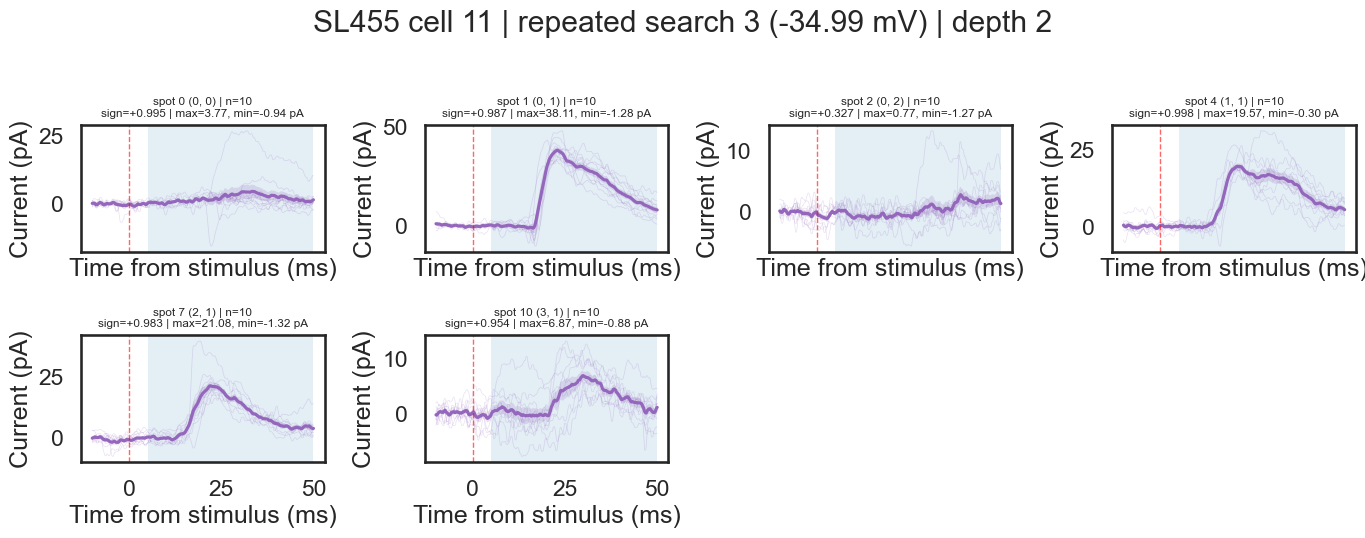

In [ ]:
test_hotspot_sign_df, test_analysis_log_df, test_figures = run_accuracy_check(
    accuracy_dataset_cache,
    ACCURACY_CELL_ID,
    sign_mode='auc',
    auc_window_ms=[5,50],
)

if test_hotspot_sign_df.empty:
    print("No valid hotspots were available to plot for the accuracy check. Potentially because DEPTH_CHOICE is None.")
else:
    display(test_hotspot_sign_df)

## 1. Calculate hotspot sign for each group

Each animal in `ANIMALS_TO_LOAD` uses its newest valid result folder, avoiding duplicate counting of older result snapshots. Loading is independent of the random, reward, and punish assignments. For every cell, the dedicated repeated final-depth hotspot search near −35 mV is read with `ndap.get_spot_response`, which correctly handles this special per-spot storage layout. All valid final-depth searches are cached first, regardless of depth or group. Group assignments and `MIN_FINAL_DEPTH` are then applied to that cache, so either can be changed without reloading the MATLAB files or recomputing hotspot traces.

For each spot, the repeated sweeps are averaged first. The maximum and minimum of that mean trace are measured over the repository-configured post-stimulus analysis window, and the sign is calculated as $(|max|-|min|)/(|max|+|min|)$. Spots with fewer than `MIN_SWEEPS_PER_HOTSPOT` sweeps are excluded rather than falling back to the single-sweep search map.


### Inspect the all-depth cache

The slow MATLAB loading and hotspot-metric calculation now run once in the **Load data** block before Section 0. This cell only inspects that in-memory cache.


In [ ]:
display(all_analysis_log_df)
cached_depths = sorted(
    pd.to_numeric(all_hotspot_sign_df["final_depth"], errors="coerce")
    .dropna()
    .astype(int)
    .unique()
)
print(
    f"Using {len(all_hotspot_sign_df)} cached hotspots at final depths "
    f"{cached_depths}."
)


,group,animal,results_folder,cell,search_idx,final_depth,status,n_hotspots
0,None,SL458,Results-20260723,5,6,5,analyzed,5
1,None,SL458,Results-20260723,6,6,5,analyzed,52
2,None,SL452,Results-20260706,2,6,4,analyzed,171
3,None,SL452,Results-20260706,5,6,4,analyzed,9
4,None,SL452,Results-20260706,6,6,5,analyzed,13
5,None,SL452,Results-20260706,7,5,2,analyzed,12
6,None,SL452,Results-20260706,8,2,4,analyzed,104
7,None,SL452,Results-20260706,9,6,3,analyzed,16
8,None,SL468,Results-20260821,2,6,3,analyzed,5
9,None,SL468,Results-20260821,5,6,2,analyzed,15


Using 1767 cached hotspots at final depths [np.int64(2), np.int64(3), np.int64(4), np.int64(5)].


### Check patch-day dopamine slope

Using the patch-day traces loaded before Section 0, identify the session under `Recordings/202606-Photometry-DMD`. Valid names follow `<YYYYMMDD>-<animal>-RewardPatch[_g#]` or `<YYYYMMDD>-<animal>-PunishPatch[_g#]`; `PrePatch` sessions are excluded. The Patch-session date is used directly because `Results-*` records the analysis/export date and often differs from the recording date. From `analysis_<session>.mat`, select the unique `Stim only`/`dLight` row and load its signed `stageAmp` response through `ndap.load_analysis_stage_response`.

With `SLOPE_WINDOW = None`, independently fit each feasible final-trial window from 15 through 40 trials and average those slopes; windows longer than the animal's recording are omitted. If fewer than 15 trials are available, fit one slope across all available trials. With an explicit window such as `SLOPE_WINDOW = 15` or `20`, fit that final window when enough trials exist; otherwise, fit one slope across the animal's entire available session. `NUM_GROUPS = 3` orders the k-means centers as dopamine `decrease`, `stable`, and `increase`; `NUM_GROUPS = 2` orders them as `decrease` and `increase`.

In [ ]:
SLOPE_WINDOW = None  # Use all trials when a session is shorter than 15.
DA_SMOOTHING_WINDOW = 5
NUM_GROUPS = 2  # 3: decrease/stable/increase; 2: decrease/increase.

,animal,patch_date,session,event,amplitude_source,n_trials,n_finite_trials,slope_windows_used,dopamine_slope,dopamine_group,cluster_center
0,SL448,20260703,20260703-SL448-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,15:31 average,-0.065335,decrease,-0.001417
1,SL468,20260820,20260820-SL468-RewardPatch_g0,Stim only,stageMax/stageMin fallback,39,39,15:39 average,-0.017527,decrease,-0.001417
2,SL469,20260819,20260819-SL469-PunishPatch_g0,Stim only,stageMax/stageMin fallback,37,37,15:37 average,-0.013563,decrease,-0.001417
3,SL455,20260729,20260729-SL455-RewardPatch_g0,Stim only,stageMax/stageMin fallback,33,33,15:33 average,0.009519,decrease,-0.001417
4,SL453,20260721,20260721-SL453-PunishPatch_g0,Stim only,stageMax/stageMin fallback,24,24,15:24 average,0.019543,decrease,-0.001417
5,SL457,20260814,20260814-SL457-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,15:31 average,0.020701,decrease,-0.001417
6,SL454,20260728,20260728-SL454-PunishPatch_g0,Stim only,stageMax/stageMin fallback,31,31,15:31 average,0.036745,decrease,-0.001417
7,SL456,20260813,20260813-SL456-RewardPatch_g0,Stim only,stageMax/stageMin fallback,14,14,14,0.117417,increase,0.117417


,n_animals,cluster_center,animals
dopamine_group,,,
decrease,7,-0.001417,"[SL448, SL468, SL469, SL455, SL453, SL457, SL454]"
increase,1,0.117417,[SL456]


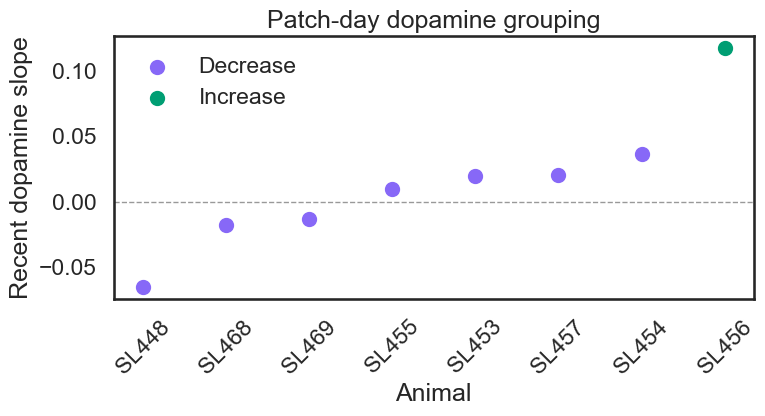

In [ ]:
from sklearn.cluster import KMeans


DA_KMEANS_RANDOM_STATE = 2626
if (
    isinstance(NUM_GROUPS, (bool, np.bool_))
    or not isinstance(NUM_GROUPS, (int, np.integer))
    or int(NUM_GROUPS) not in (2, 3)
):
    raise ValueError("NUM_GROUPS must be the integer 2 or 3.")
NUM_GROUPS = int(NUM_GROUPS)
DA_GROUP_ORDER = (
    ["decrease", "increase"]
    if NUM_GROUPS == 2
    else ["decrease", "stable", "increase"]
)
DA_GROUP_COLORS = {
    "decrease": [135 / 255, 104 / 255, 247 / 255],
    "stable": [198 / 255, 156 / 255, 109 / 255],
    "increase": [0 / 255, 158 / 255, 115 / 255],
}


def recent_dopamine_slope(stage_amp, slope_window=None):
    """Fit and average the requested final-trial dopamine slopes."""
    response = np.asarray(stage_amp, dtype=float).ravel()
    if len(response) < 3:
        raise ValueError("At least three Stim only trials are required.")

    # Match MATLAB smoothdata(response, 'movmean', 5), including endpoints.
    smoothed = (
        pd.Series(response)
        .rolling(DA_SMOOTHING_WINDOW, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )
    if slope_window is None:
        windows = np.arange(15, 41, dtype=int)
    else:
        if not isinstance(slope_window, (int, np.integer)) or slope_window < 3:
            raise ValueError("SLOPE_WINDOW must be None or an integer >= 3.")
        windows = np.asarray([slope_window], dtype=int)
    feasible_windows = windows[windows <= len(response)]
    if len(feasible_windows) == 0:
        # A requested window longer than the recording falls back to
        # one slope fitted across the whole available session.
        feasible_windows = np.asarray([len(response)], dtype=int)
    windows = feasible_windows

    slopes = []
    for window in windows:
        segment = smoothed[-int(window):]
        trial = np.arange(1, len(segment) + 1, dtype=float)
        finite = np.isfinite(segment)
        slopes.append(
            np.polyfit(trial[finite], segment[finite], 1)[0]
            if finite.sum() >= 3 else np.nan
        )
    if not np.isfinite(slopes).any():
        raise ValueError("No finite dopamine slopes could be fitted.")
    return (
        float(np.nanmean(slopes)), np.asarray(slopes), windows, smoothed
    )


# Calculate slopes from the already-loaded raw responses.
dopamine_records = []
dopamine_traces = {}
for animal in DOPAMINE_ANIMALS:
    cached = patch_data_cache[animal]
    stage_amp = cached["stage_amp"]
    slope, fitted_slopes, fitted_windows, smoothed = recent_dopamine_slope(
        stage_amp, SLOPE_WINDOW
    )
    dopamine_records.append({
        "animal": animal,
        "patch_date": cached["patch_date"],
        "session": cached["session"],
        "event": cached["event"],
        "amplitude_source": cached["amplitude_source"],
        "n_trials": len(stage_amp),
        "n_finite_trials": int(np.isfinite(stage_amp).sum()),
        "slope_windows_used": (
            f"{fitted_windows[0]}:{fitted_windows[-1]} average"
            if len(fitted_windows) > 1 else int(fitted_windows[0])
        ),
        "dopamine_slope": slope,
    })
    dopamine_traces[animal] = {
        "stage_amp": stage_amp,
        "smoothed": smoothed,
        "window_lengths": fitted_windows,
        "window_slopes": fitted_slopes,
    }

dopamine_slope_df = pd.DataFrame(dopamine_records)
if (
    len(dopamine_slope_df) < NUM_GROUPS
    or dopamine_slope_df["dopamine_slope"].nunique() < NUM_GROUPS
):
    raise ValueError(
        f"{NUM_GROUPS}-group k-means requires at least "
        f"{NUM_GROUPS} distinct animal slopes."
    )

kmeans = KMeans(
    n_clusters=NUM_GROUPS, n_init=100,
    random_state=DA_KMEANS_RANDOM_STATE,
)
raw_labels = kmeans.fit_predict(dopamine_slope_df[["dopamine_slope"]])
center_order = np.argsort(kmeans.cluster_centers_.ravel())
label_by_cluster = {
    int(cluster): DA_GROUP_ORDER[rank]
    for rank, cluster in enumerate(center_order)
}
dopamine_slope_df["dopamine_group"] = [
    label_by_cluster[int(label)] for label in raw_labels
]
dopamine_slope_df["cluster_center"] = [
    float(kmeans.cluster_centers_[int(label), 0]) for label in raw_labels
]
dopamine_slope_df["dopamine_group"] = pd.Categorical(
    dopamine_slope_df["dopamine_group"],
    categories=DA_GROUP_ORDER,
    ordered=True,
)
dopamine_slope_df = dopamine_slope_df.sort_values(
    ["dopamine_group", "dopamine_slope", "animal"]
).reset_index(drop=True)

dopamine_group_animals = {
    group: dopamine_slope_df.loc[
        dopamine_slope_df["dopamine_group"] == group, "animal"
    ].tolist()
    for group in DA_GROUP_ORDER
}
dopamine_group_by_animal = {
    row.animal: str(row.dopamine_group)
    for row in dopamine_slope_df.itertuples(index=False)
}
decrease_animals = dopamine_group_animals["decrease"]
stable_animals = dopamine_group_animals.get("stable", [])
increase_animals = dopamine_group_animals["increase"]

display(dopamine_slope_df)
display(
    dopamine_slope_df.groupby("dopamine_group", observed=False)
    .agg(
        n_animals=("animal", "size"),
        cluster_center=("cluster_center", "first"),
        animals=("animal", lambda values: list(values)),
    )
)

fig, ax = plt.subplots(
    figsize=(max(8, 0.8 * len(dopamine_slope_df)), 4.5)
)
for group in DA_GROUP_ORDER:
    rows = dopamine_slope_df[
        dopamine_slope_df["dopamine_group"] == group
    ]
    ax.scatter(
        rows["animal"], rows["dopamine_slope"], s=90,
        color=DA_GROUP_COLORS[group], label=group.capitalize(), zorder=3,
    )
ax.axhline(0, color="0.6", linestyle="--", linewidth=1)
ax.set_xlabel("Animal")
ax.set_ylabel("Recent dopamine slope")
ax.set_title("Patch-day dopamine grouping")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()



### Apply groups and depth criteria to animals

Choose `GROUPING_MODE = "task"` for the original random/reward/punish assignment, or `GROUPING_MODE = "dopamine"` for random plus the dopamine groups selected by `NUM_GROUPS`. Dopamine mode requires the patch-day slope cell above to be run first. The random animals remain a separate group and are not included in dopamine k-means. Set `EXCLUDE_ANIMALS = True` and list animal IDs in `ANIMALS_TO_EXCLUDE` to remove all of their cells and hotspots from downstream analyses while retaining an exclusion record in `analysis_log_df`.

In [ ]:
# Update configuration if needed.

GROUPING_MODE = "task"  # "task" or "dopamine"
MIN_FINAL_DEPTH = 3  # Inclusive cutoff; set to None to keep every depth.
MIN_SWEEPS_PER_HOTSPOT = 5
PLOT_WINDOW_MS = (-10.0, 50.0)

# Exclude every cell/hotspot belonging to the listed animals.
EXCLUDE_ANIMALS = False
ANIMALS_TO_EXCLUDE = ["SL455"]
GROUP_LABEL_FONTSIZE = 10

In [ ]:
def filter_hotspots_by_final_depth(hotspot_df, log_df, minimum_depth):
    """Return independent metric and log tables passing the cutoff."""
    filtered_hotspots = hotspot_df.copy()
    filtered_log = log_df.copy()
    if minimum_depth is None:
        return filtered_hotspots, filtered_log

    try:
        minimum_depth = float(minimum_depth)
    except (TypeError, ValueError) as error:
        raise ValueError("MIN_FINAL_DEPTH must be numeric or None.") from error
    if not np.isfinite(minimum_depth):
        raise ValueError("MIN_FINAL_DEPTH must be finite or None.")

    hotspot_depths = pd.to_numeric(
        filtered_hotspots["final_depth"], errors="coerce"
    )
    filtered_hotspots = filtered_hotspots.loc[
        hotspot_depths >= minimum_depth
    ].copy()

    log_depths = pd.to_numeric(filtered_log["final_depth"], errors="coerce")
    excluded = log_depths.notna() & (log_depths < minimum_depth)
    filtered_log.loc[excluded, "status"] = log_depths.loc[excluded].map(
        lambda depth: (
            f"excluded: final depth {depth:g} < minimum "
            f"{minimum_depth:g}"
        )
    )
    filtered_log.loc[excluded, "n_hotspots"] = 0
    return filtered_hotspots, filtered_log


def filter_excluded_animals(
    hotspot_df, log_df, enabled, animals_to_exclude
):
    """Remove listed animals while preserving their exclusion log rows."""
    filtered_hotspots = hotspot_df.copy()
    filtered_log = log_df.copy()
    if not isinstance(enabled, (bool, np.bool_)):
        raise TypeError("EXCLUDE_ANIMALS must be True or False.")
    if not enabled:
        return filtered_hotspots, filtered_log

    if isinstance(animals_to_exclude, str):
        raise TypeError(
            "ANIMALS_TO_EXCLUDE must be a sequence of animal IDs, "
            "not a single string."
        )
    excluded_ids = {
        str(animal).strip().casefold()
        for animal in animals_to_exclude
        if str(animal).strip()
    }
    if not excluded_ids:
        return filtered_hotspots, filtered_log

    hotspot_excluded = (
        filtered_hotspots["animal"].astype(str).str.casefold()
        .isin(excluded_ids)
    )
    filtered_hotspots = filtered_hotspots.loc[~hotspot_excluded].copy()

    log_excluded = (
        filtered_log["animal"].astype(str).str.casefold()
        .isin(excluded_ids)
    )
    filtered_log.loc[log_excluded, "status"] = (
        "excluded: animal listed in ANIMALS_TO_EXCLUDE"
    )
    filtered_log.loc[log_excluded, "n_hotspots"] = 0
    return filtered_hotspots, filtered_log


def apply_group_assignments(hotspot_df, log_df, group_by_animal):
    """Label cached animals and exclude those without a current group."""
    grouped_hotspots = hotspot_df.copy()
    grouped_log = log_df.copy()
    grouped_hotspots["group"] = grouped_hotspots["animal"].map(
        group_by_animal
    )
    grouped_log["group"] = grouped_log["animal"].map(group_by_animal)

    grouped_hotspots = grouped_hotspots.loc[
        grouped_hotspots["group"].notna()
    ].copy()
    unassigned = grouped_log["animal"].notna() & grouped_log["group"].isna()
    grouped_log.loc[unassigned, "status"] = (
        "excluded: animal not assigned to a group"
    )
    grouped_log.loc[unassigned, "n_hotspots"] = 0
    return grouped_hotspots, grouped_log


# Keep group labels, plot colors, and endpoint comparisons synchronized.
grouping_mode = str(GROUPING_MODE).strip().casefold()
if grouping_mode == "task":
    GROUP_ORDER = TASK_GROUP_ORDER.copy()
    GROUP_COLORS = TASK_GROUP_COLORS.copy()
    animal_groups = {
        "random": random_animals,
        "reward": reward_animals,
        "punish": punish_animals,
    }
    COMPARISON_GROUPS = ("reward", "punish")
elif grouping_mode == "dopamine":
    if "dopamine_group_animals" not in globals():
        raise RuntimeError(
            "Run the patch-day dopamine slope cell before using "
            "GROUPING_MODE='dopamine'."
        )
    GROUP_ORDER = ["random", *DA_GROUP_ORDER]
    GROUP_COLORS = {
        "random": TASK_GROUP_COLORS["random"],
        **{group: DA_GROUP_COLORS[group] for group in DA_GROUP_ORDER},
    }
    animal_groups = {
        "random": random_animals,
        **{group: dopamine_group_animals[group] for group in DA_GROUP_ORDER},
    }
    COMPARISON_GROUPS = ("decrease", "increase")
else:
    raise ValueError(
        "GROUPING_MODE must be either 'task' or 'dopamine'; "
        f"received {GROUPING_MODE!r}."
    )

BASELINE_GROUP, COMPARISON_GROUP = COMPARISON_GROUPS
group_by_animal = resolve_group_assignments(
    ANIMALS_TO_LOAD, animal_groups
)
depth_filtered_df, depth_filtered_log_df = filter_hotspots_by_final_depth(
    all_hotspot_sign_df, all_analysis_log_df, MIN_FINAL_DEPTH
)
analysis_ready_df, analysis_ready_log_df = filter_excluded_animals(
    depth_filtered_df,
    depth_filtered_log_df,
    EXCLUDE_ANIMALS,
    ANIMALS_TO_EXCLUDE,
)
hotspot_sign_df, analysis_log_df = apply_group_assignments(
    analysis_ready_df, analysis_ready_log_df, group_by_animal
)
display(analysis_log_df)
if hotspot_sign_df.empty:
    raise ValueError(
        "No cached hotspots remain after applying the current group "
        f"assignments and MIN_FINAL_DEPTH={MIN_FINAL_DEPTH}."
    )

unique_cell_counts = (
    hotspot_sign_df[["group", "animal", "results_folder", "cell"]]
    .drop_duplicates()
    .groupby("group", observed=True)
    .size()
)
group_summary_df = (
    hotspot_sign_df.groupby("group", observed=True)
    .agg(
        n_hotspots=("hotspot_sign", "size"),
        n_animals=("animal", "nunique"),
        median_sign=("hotspot_sign", "median"),
        mean_sign=("hotspot_sign", "mean"),
    )
)
group_summary_df.insert(2, "n_cells", unique_cell_counts)
group_summary_df = group_summary_df.reindex(GROUP_ORDER)
display(group_summary_df)
# hotspot_sign_df.head()


,group,animal,results_folder,cell,search_idx,final_depth,status,n_hotspots
0,random,SL458,Results-20260723,5,6,5,analyzed,5
1,random,SL458,Results-20260723,6,6,5,analyzed,52
2,random,SL452,Results-20260706,2,6,4,analyzed,171
3,random,SL452,Results-20260706,5,6,4,analyzed,9
4,random,SL452,Results-20260706,6,6,5,analyzed,13
5,random,SL452,Results-20260706,7,5,2,excluded: final depth 2 < minimum 3,0
6,random,SL452,Results-20260706,8,2,4,analyzed,104
7,random,SL452,Results-20260706,9,6,3,analyzed,16
8,reward,SL468,Results-20260821,2,6,3,analyzed,5
9,reward,SL468,Results-20260821,5,6,2,excluded: final depth 2 < minimum 3,0


,n_hotspots,n_animals,n_cells,median_sign,mean_sign
group,,,,,
random,370,2,7,1.0,0.162162
reward,841,3,14,-1.0,-0.101070
punish,488,4,13,1.0,0.073770


## 2. Plot hotspot sign distributions

The shared NeuroDAP distribution plot shows permutation-bootstrap means in the upper panel and empirical CDFs of the same hotspot-level values below. Positive values indicate a positive-going-current-dominated hotspot; negative values indicate a negative-going-current-dominated hotspot.

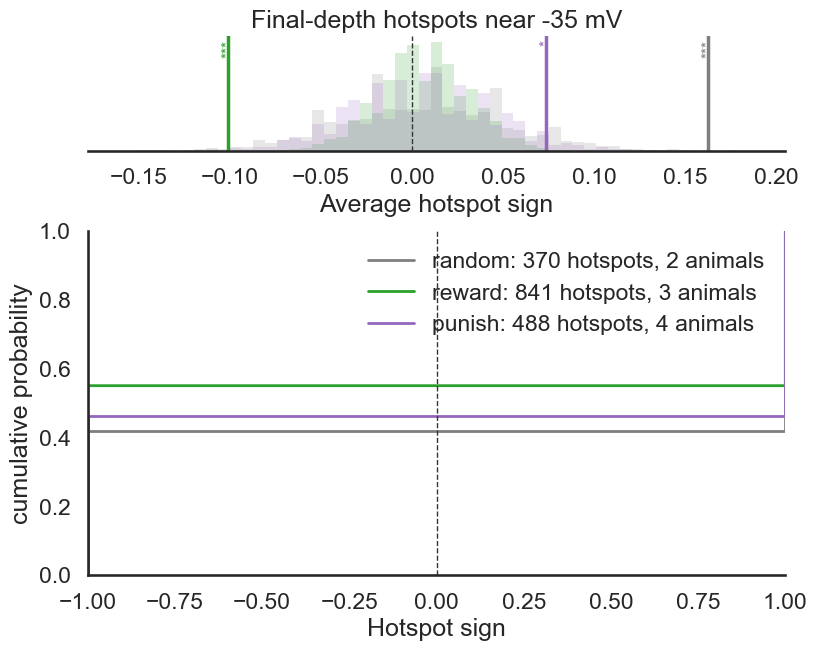

In [ ]:
distribution_groups = []
for group in GROUP_ORDER:
    group_rows = hotspot_sign_df[hotspot_sign_df["group"] == group]
    values = group_rows["hotspot_sign"].dropna().to_numpy(dtype=float)
    if len(values) == 0:
        continue
    distribution_groups.append((group, group_rows, values))

if not distribution_groups:
    raise ValueError("No finite hotspot signs are available to plot.")

boot_data, boot_indices = ndap.generate_boot_data(
    [values for _, _, values in distribution_groups],
    random_state=2026,
)
fig, distribution_placeholder = plt.subplots(figsize=(9, 7))
distribution_axes = None
for (group, group_rows, values), boot_idx in zip(
    distribution_groups, boot_indices
):
    label = (
        f"{group}: {len(values)} hotspots, "
        f"{group_rows['animal'].nunique()} animals"
    )
    fig, distribution_axes = ndap.plot_distribution(
        values,
        label=label,
        color=GROUP_COLORS[group],
        ax=distribution_placeholder,
        boot_data=boot_data,
        boot_idx=boot_idx,
        xlabel="Hotspot sign",
        top_xlabel="Average hotspot sign",
        show_legend=True,
        title=f"Final-depth hotspots near {TARGET_VHOLD_MV:g} mV",
    )

ax_mean, ax_cdf = distribution_axes
for ax in (ax_mean, ax_cdf):
    ax.axvline(0, color="0.2", linestyle="--", linewidth=1)
ax_cdf.set_xlim(-1, 1)
plt.show()

## 3. Compare spot response with minis

Compare each cell's repeated-hotspot response with minis detected in the paired non-stimulation `baselineMap` sweeps.

The detector is an in-memory, sampling-rate-aware adaptation of [ellamcho/mini_detect's `functions.py`](https://github.com/ellamcho/mini_detect/blob/main/Code/functions.py). It applies the same 1–3000 Hz, second-order Butterworth filter; searches for polarity-specific monotonic decay windows; selects the local extremum near each decay start; and rejects candidates using a median-baseline noise gate plus the original amplitude limits (negative < −8 pA; positive between 8 and 60 pA).

The workflow is deliberately split into two stages:

1. **Load once before Section 0:** cache raw `baselineMap` segments for every hotspot, retaining the selector that links each segment to its source hotspot.
2. **Analyze repeatedly here:** select the currently retained hotspot rows, detect minis only in their cached controls, calculate summaries, and plot validation traces. Changing grouping, depth, exclusions, `MINI_CONFIG`, or `MINI_CELL_SUMMARY` does not reopen the source files.

Each baseline sweep is filtered and searched independently so sweep boundaries cannot create events. The source detector's 60 ms positive-event decay window is shortened below to 20 ms because these `baselineMap` controls are only about 30 ms long. Negative-going events are treated as mEPSC-like and positive-going events as mIPSC-like at approximately −35 mV.

In [ ]:
# Mini detection, summarization, and plotting helpers

def summarize_mini_values(values, method):
    """Return a finite median or mean, or NaN when no values are available."""
    numeric = pd.to_numeric(pd.Series(values), errors="coerce")
    numeric = numeric[np.isfinite(numeric)].to_numpy(dtype=float)
    if len(numeric) == 0:
        return np.nan
    if method == "median":
        return float(np.median(numeric))
    if method == "mean":
        return float(np.mean(numeric))
    raise ValueError("summary must be 'median' or 'mean'")


def analyze_hotspot_mini_data(
    mini_data_cache, hotspot_df, config, summary="median"
):
    """Detect minis for the currently retained rows in the raw cache."""
    if summary not in {"median", "mean"}:
        raise ValueError("summary must be 'median' or 'mean'")
    required = set(MINI_CELL_KEY_COLUMNS + MINI_SELECTOR_COLUMNS) | {
        "group", "max_current_pa", "min_current_pa"
    }
    missing = required.difference(hotspot_df.columns)
    if missing:
        raise ValueError(f"hotspot_df is missing columns: {sorted(missing)}")

    retained_cells = {
        (str(animal), str(results_folder), int(cell_id)): rows
        for (animal, results_folder, cell_id), rows in hotspot_df.groupby(
            MINI_CELL_KEY_COLUMNS, observed=True, sort=False
        )
    }
    summaries = []
    analysis_logs = []
    analysis_records = {}
    for cache_key, rows in retained_cells.items():
        cached = mini_data_cache.get(cache_key)
        groups = rows["group"].dropna().unique()
        metadata = {
            "group": groups[0] if len(groups) == 1 else None,
            "animal": cache_key[0],
            "results_folder": cache_key[1],
            "cell": cache_key[2],
        }
        if cached is None:
            analysis_logs.append({
                **metadata, "status": "no cached mini-control data"
            })
            continue
        if len(groups) != 1:
            analysis_logs.append({
                **metadata, "status": "cell has ambiguous group labels"
            })
            continue

        selectors = {
            mini_selector_key(*values)
            for values in rows[MINI_SELECTOR_COLUMNS]
            .drop_duplicates()
            .itertuples(index=False, name=None)
        }
        segments = tuple(
            segment
            for selector in selectors
            for segment in cached["segments_by_selector"].get(selector, ())
        )
        if not segments:
            analysis_logs.append({
                **metadata,
                "status": "no cached controls for retained hotspots",
            })
            continue

        try:
            detection = ndap.detect_minis(
                segments, cached["sample_rate_hz"], config
            )
        except (TypeError, ValueError) as error:
            analysis_logs.append({
                **metadata, "status": f"mini detection error: {error}"
            })
            continue

        events = detection.events
        negative_events = events[events["polarity"] == "negative"]
        positive_events = events[events["polarity"] == "positive"]
        thresholds = detection.thresholds.groupby("polarity")[
            "noise_threshold_pa"
        ].median()
        duration_s = sum(map(len, segments)) / cached["sample_rate_hz"]
        hotspot_min = summarize_mini_values(
            rows["min_current_pa"], summary
        )
        hotspot_max = summarize_mini_values(
            rows["max_current_pa"], summary
        )
        mini_min = summarize_mini_values(
            negative_events["amplitude_pa"], summary
        )
        mini_max = summarize_mini_values(
            positive_events["amplitude_pa"], summary
        )

        summaries.append({
            **metadata,
            "n_hotspots": len(rows),
            "n_control_segments": len(segments),
            "control_duration_s": duration_s,
            "negative_noise_threshold_pa": thresholds.get(
                "negative", np.nan
            ),
            "positive_noise_threshold_pa": thresholds.get(
                "positive", np.nan
            ),
            "n_negative_minis": len(negative_events),
            "n_positive_minis": len(positive_events),
            "negative_mini_rate_hz": len(negative_events) / duration_s,
            "positive_mini_rate_hz": len(positive_events) / duration_s,
            "hotspot_min_pa": hotspot_min,
            "mini_min_pa": mini_min,
            "min_difference_pa": hotspot_min - mini_min,
            "hotspot_max_pa": hotspot_max,
            "mini_max_pa": mini_max,
            "max_difference_pa": hotspot_max - mini_max,
        })
        analysis_records[cache_key] = {
            **cached,
            **metadata,
            "hotspot_rows": rows.copy(),
            "segments": segments,
            "filtered_segments": detection.filtered_segments,
            "events": events,
            "thresholds": detection.thresholds,
            "config": config,
        }

        missing_polarities = [
            label
            for label, count in (
                ("negative", len(negative_events)),
                ("positive", len(positive_events)),
            )
            if count == 0
        ]
        status = (
            "analyzed"
            if not missing_polarities
            else f"analyzed; no {'/'.join(missing_polarities)} minis detected"
        )
        analysis_logs.append({**metadata, "status": status})

    return (
        pd.DataFrame.from_records(summaries),
        pd.DataFrame.from_records(analysis_logs),
        analysis_records,
    )


def plot_mini_detection_validation(
    analysis_records,
    cells_per_figure=6,
    max_seconds=None,
):
    """Plot filtered cached controls and every accepted mini event."""
    if cells_per_figure < 1:
        raise ValueError("cells_per_figure must be at least 1")

    figures = []
    items = list(analysis_records.items())
    for page_start in range(0, len(items), cells_per_figure):
        page = items[page_start:page_start + cells_per_figure]
        fig, axes = plt.subplots(
            len(page), 1, figsize=(13, 2.5 * len(page)), squeeze=False
        )
        for ax, (_, record) in zip(axes[:, 0], page):
            sample_rate_hz = record["sample_rate_hz"]
            sample_limit = (
                np.inf
                if max_seconds is None
                else int(max_seconds * sample_rate_hz)
            )
            offset = 0
            labels_used = set()
            for segment_idx, segment in enumerate(
                record["filtered_segments"]
            ):
                remaining = sample_limit - offset
                if remaining <= 0:
                    break
                n_plot = (
                    len(segment)
                    if np.isinf(remaining)
                    else min(len(segment), int(remaining))
                )
                time_s = (
                    offset + np.arange(n_plot)
                ) / sample_rate_hz
                ax.plot(
                    time_s, segment[:n_plot],
                    color="0.25", linewidth=0.7,
                )
                segment_events = record["events"]
                segment_events = segment_events[
                    (segment_events["segment_idx"] == segment_idx)
                    & (segment_events["sample"] < n_plot)
                ]
                for polarity, marker, color, label in (
                    ("negative", "v", "tab:blue", "mEPSC-like"),
                    ("positive", "^", "tab:red", "mIPSC-like"),
                ):
                    detected = segment_events[
                        segment_events["polarity"] == polarity
                    ]
                    if detected.empty:
                        continue
                    samples = detected["sample"].to_numpy(dtype=int)
                    ax.scatter(
                        (offset + samples) / sample_rate_hz,
                        segment[samples],
                        s=28,
                        marker=marker,
                        color=color,
                        zorder=3,
                        label=(
                            label
                            if label not in labels_used
                            else "_nolegend_"
                        ),
                    )
                    labels_used.add(label)
                offset += n_plot

            events = record["events"]
            n_negative = int(
                (events["polarity"] == "negative").sum()
            )
            n_positive = int(
                (events["polarity"] == "positive").sum()
            )
            ax.axhline(0, color="0.75", linewidth=0.8)
            ax.set_title(
                f"{record['animal']} cell {record['cell']} "
                f"({record['group']}) | "
                f"mEPSC-like n={n_negative}, "
                f"mIPSC-like n={n_positive}",
                fontsize=9,
            )
            ax.set_ylabel("Filtered current (pA)")
            if labels_used:
                ax.legend(
                    frameon=False, fontsize=8, loc="upper right"
                )
        axes[-1, 0].set_xlabel("Cumulative control time shown (s)")
        fig.tight_layout()
        figures.append(fig)
    return figures



### Inspect loaded mini-control data

The raw controls for every cached hotspot are loaded before Section 0. This block only inspects the cache; current grouping, depth, and exclusion choices are applied during mini analysis below.


In [ ]:
display(mini_load_log_df)
n_cached_segments = sum(
    len(segments)
    for record in mini_data_cache.values()
    for segments in record["segments_by_selector"].values()
)
print(
    f"Using {n_cached_segments} cached control segments from "
    f"{len(mini_data_cache)} cells."
)


,animal,results_folder,cell,n_hotspots,n_control_segments,status
0,SL458,Results-20260723,5,5,50,loaded
1,SL458,Results-20260723,6,52,520,loaded
2,SL452,Results-20260706,2,171,1710,loaded
3,SL452,Results-20260706,5,9,90,loaded
4,SL452,Results-20260706,6,13,130,loaded
5,SL452,Results-20260706,7,12,120,loaded
6,SL452,Results-20260706,8,104,1040,loaded
7,SL452,Results-20260706,9,16,160,loaded
8,SL468,Results-20260821,2,5,50,loaded
9,SL468,Results-20260821,5,15,150,loaded


Using 17670 cached control segments from 41 cells.


### Configure and rerun mini detection

The raw controls were loaded before Section 0 into `mini_data_cache`. Change the detector or summary settings below and rerun from this cell without reading the result files again.

In [ ]:
# The defaults reproduce mini_detect's 10 kHz sample-count settings.
# DMD baselineMap controls are ~30 ms, so the source's 60 ms IPSC decay
# window cannot fit; use a 20 ms window and 5 ms monotonicity sampling here.
MINI_CONFIG = ndap.MiniDetectionConfig(
    ipsc_decay_window_ms=20.0,
    ipsc_decay_step_ms=5.0,
)
MINI_CELL_SUMMARY = "median"  # "median" or "mean"
MINI_VALIDATION_SECONDS = None  # Set a number to limit seconds shown.
MINI_VALIDATION_CELLS_PER_FIGURE = 6


mini_comparison_df, mini_analysis_log_df, control_trace_records = (
    analyze_hotspot_mini_data(
        mini_data_cache,
        hotspot_sign_df,
        config=MINI_CONFIG,
        summary=MINI_CELL_SUMMARY,
    )
)

,group,animal,results_folder,cell,status
0,random,SL458,Results-20260723,5,analyzed; no negative/positive minis detected
1,random,SL458,Results-20260723,6,analyzed; no positive minis detected
2,random,SL452,Results-20260706,2,analyzed
3,random,SL452,Results-20260706,5,analyzed; no negative/positive minis detected
4,random,SL452,Results-20260706,6,analyzed; no negative/positive minis detected
5,random,SL452,Results-20260706,8,analyzed
6,random,SL452,Results-20260706,9,analyzed
7,reward,SL468,Results-20260821,2,analyzed; no negative/positive minis detected
8,reward,SL468,Results-20260821,6,analyzed; no negative/positive minis detected
9,reward,SL468,Results-20260821,9,analyzed; no negative minis detected


,group,animal,results_folder,cell,n_hotspots,n_control_segments,control_duration_s,negative_noise_threshold_pa,positive_noise_threshold_pa,n_negative_minis,n_positive_minis,negative_mini_rate_hz,positive_mini_rate_hz,hotspot_min_pa,mini_min_pa,min_difference_pa,hotspot_max_pa,mini_max_pa,max_difference_pa
0,random,SL458,Results-20260723,5,5,50,1.505,-1.775847,1.819478,0,0,0.000000,0.000000,-1.178480,NaN,NaN,0.409840,NaN,NaN
1,random,SL458,Results-20260723,6,52,520,15.652,-2.252865,2.232459,16,0,1.022234,0.000000,-1.657904,-15.516933,13.859029,0.759998,NaN,NaN
2,random,SL452,Results-20260706,2,171,1710,51.471,-3.540289,3.307008,51,112,0.990849,2.175983,-1.636246,-12.283831,10.647586,2.735582,15.870318,-13.134736
3,random,SL452,Results-20260706,5,9,90,2.709,-1.275665,1.330008,0,0,0.000000,0.000000,-0.947715,NaN,NaN,0.552683,NaN,NaN
4,random,SL452,Results-20260706,6,13,130,3.913,-1.322761,1.313803,0,0,0.000000,0.000000,-1.356800,NaN,NaN,0.479782,NaN,NaN
5,random,SL452,Results-20260706,8,104,1040,31.304,-4.903057,5.127109,18,61,0.575006,1.948633,-2.161034,-11.588261,9.427226,2.966260,10.466047,-7.499787
6,random,SL452,Results-20260706,9,16,160,4.816,-6.457003,7.228512,10,14,2.076412,2.906977,-3.403507,-11.138582,7.735075,1.483741,10.848260,-9.364519
7,reward,SL468,Results-20260821,2,5,50,1.505,-1.510789,1.995091,0,0,0.000000,0.000000,-0.901475,NaN,NaN,8.248010,NaN,NaN
8,reward,SL468,Results-20260821,6,7,70,2.107,-1.352887,1.287241,0,0,0.000000,0.000000,-0.518533,NaN,NaN,2.703180,NaN,NaN
9,reward,SL468,Results-20260821,9,6,60,1.806,-1.123899,1.803605,0,1,0.000000,0.553710,-0.569699,NaN,NaN,1.773314,9.054928,-7.281613


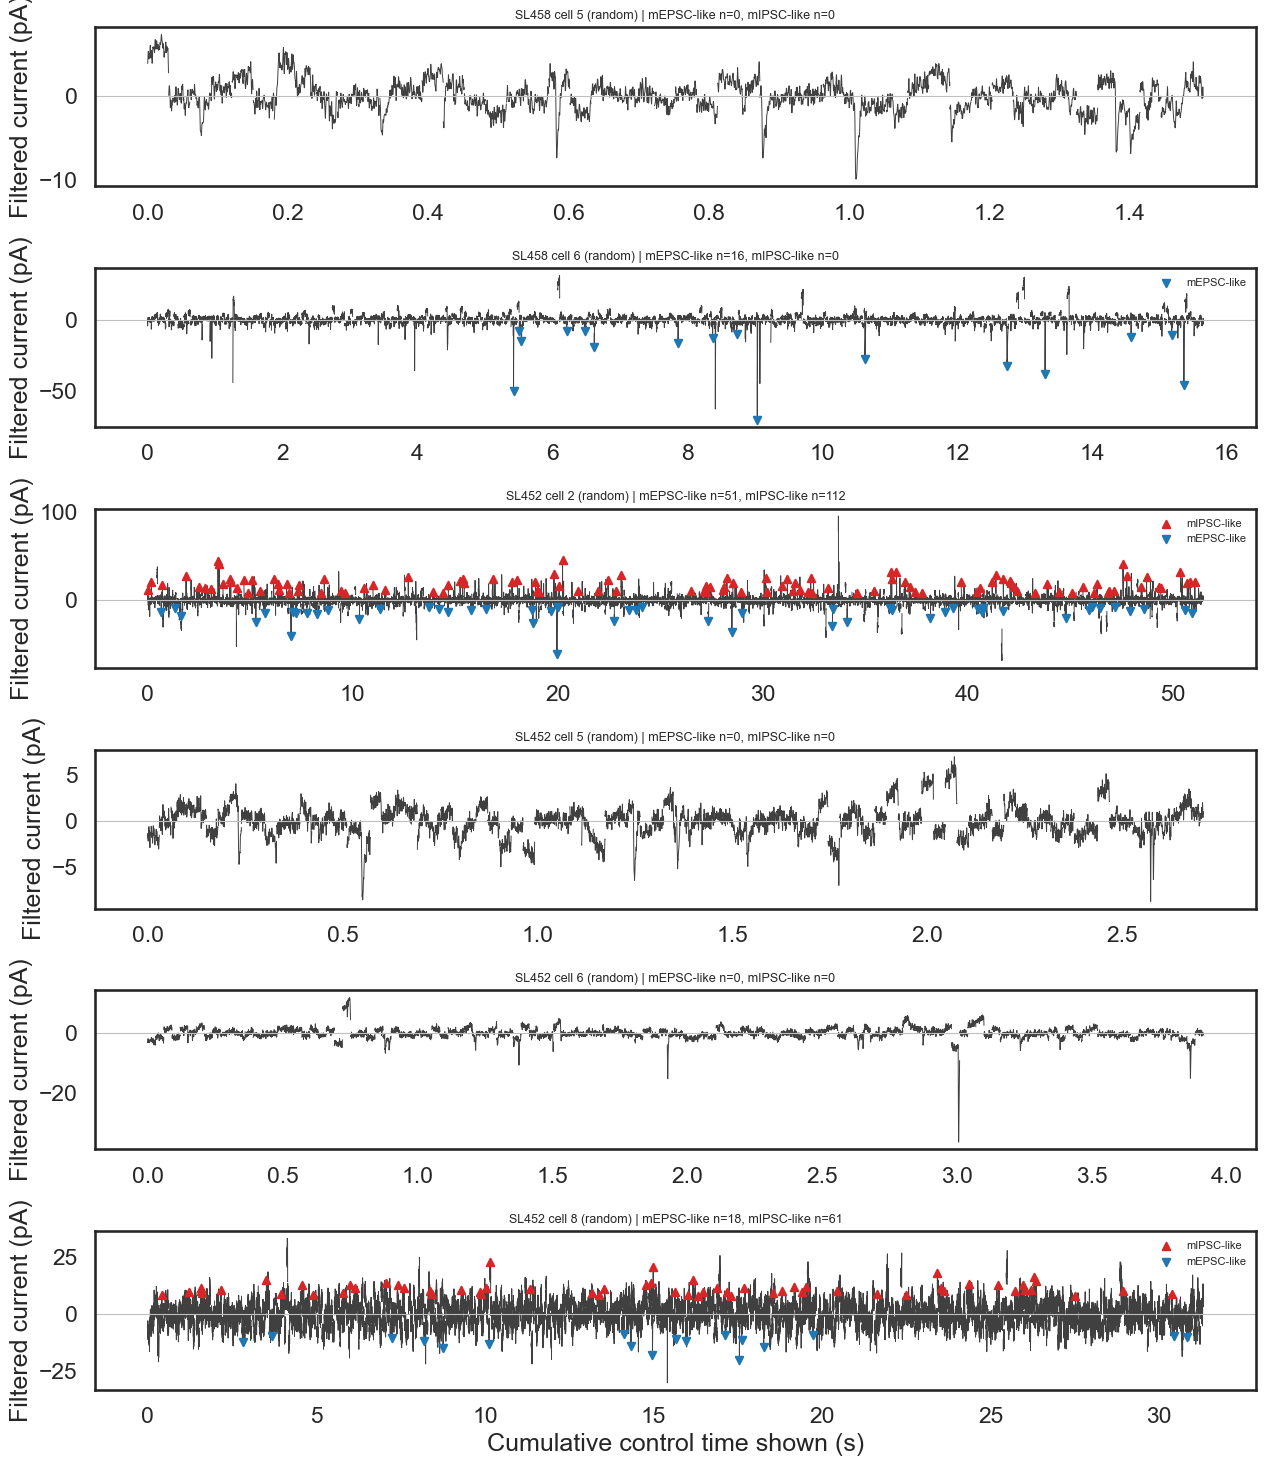

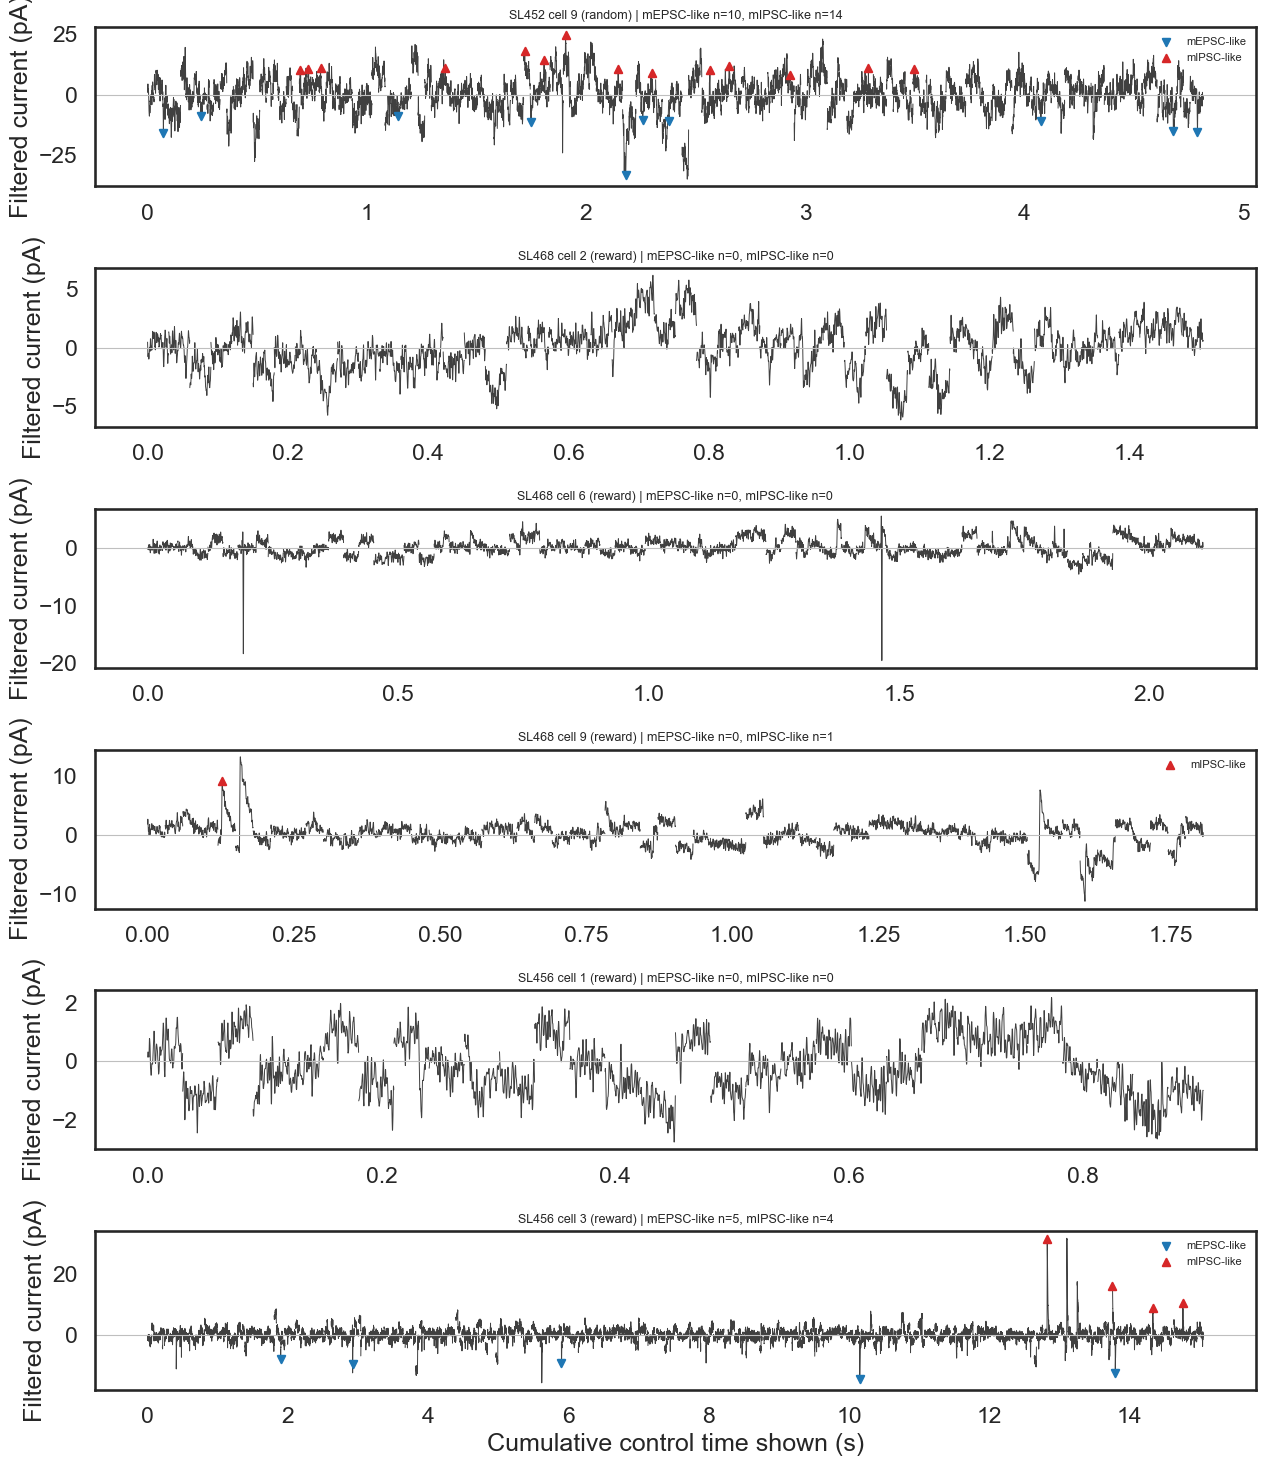

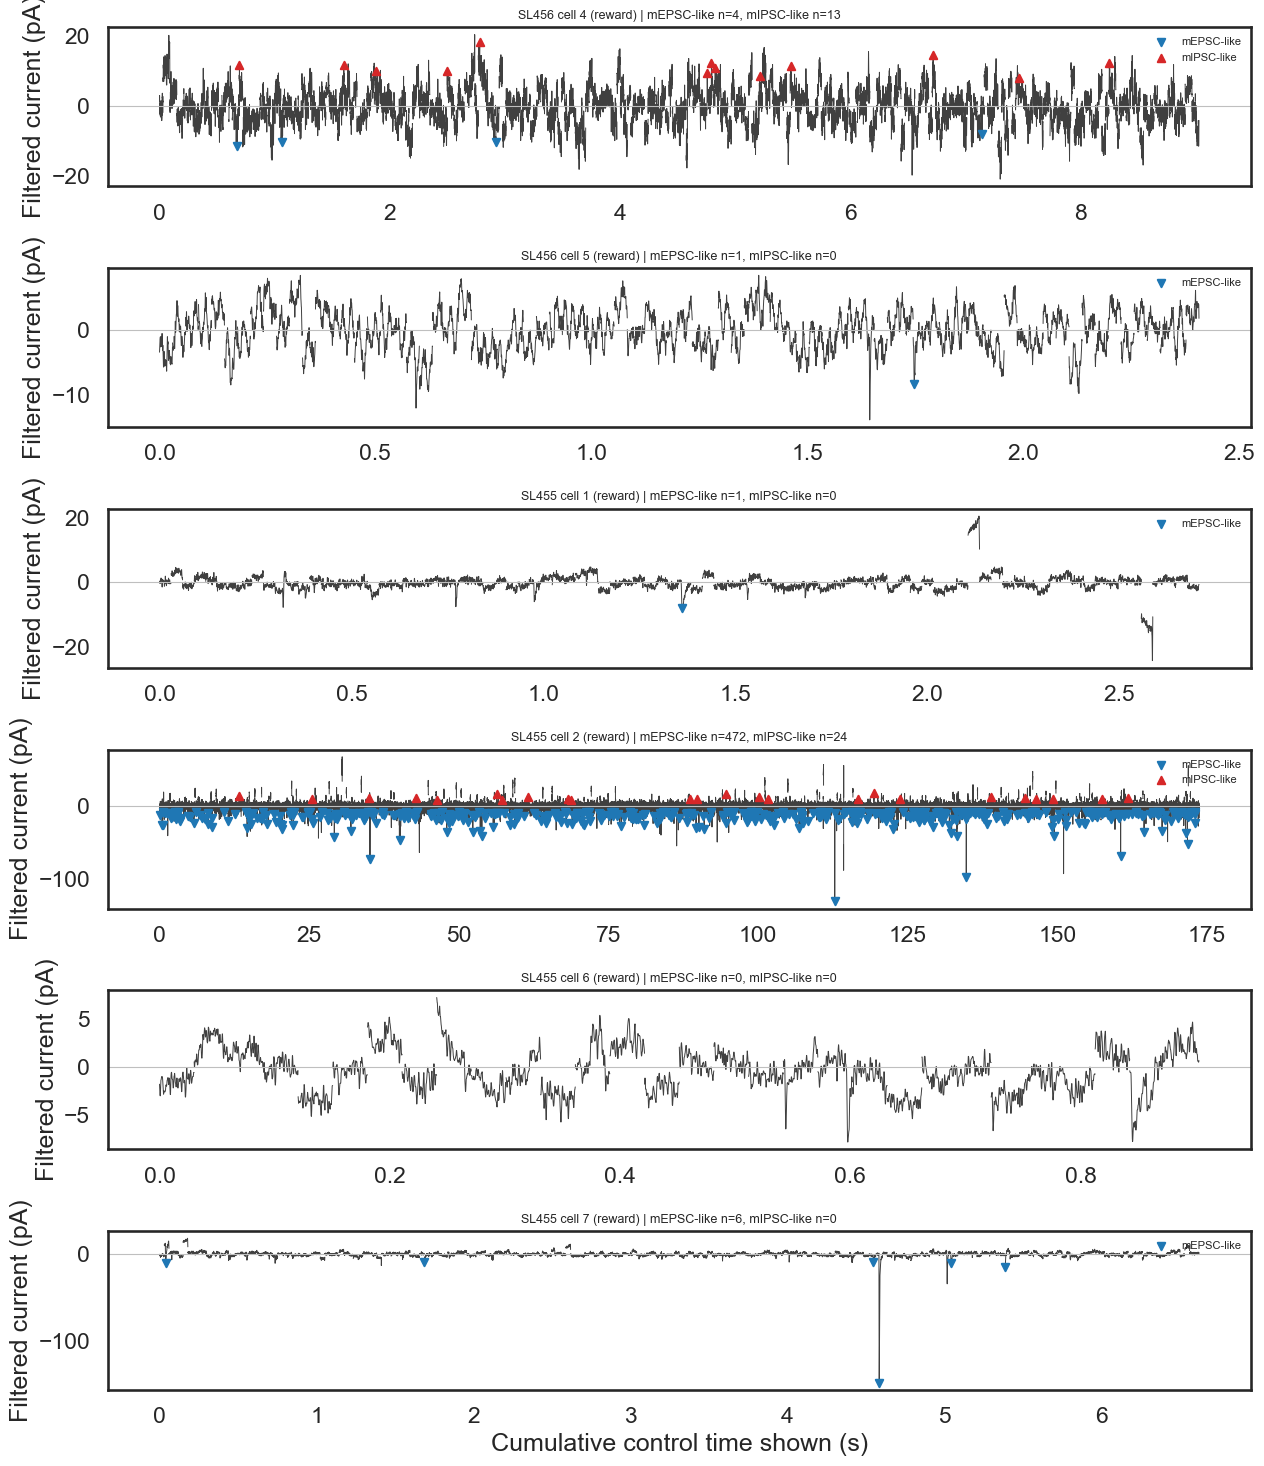

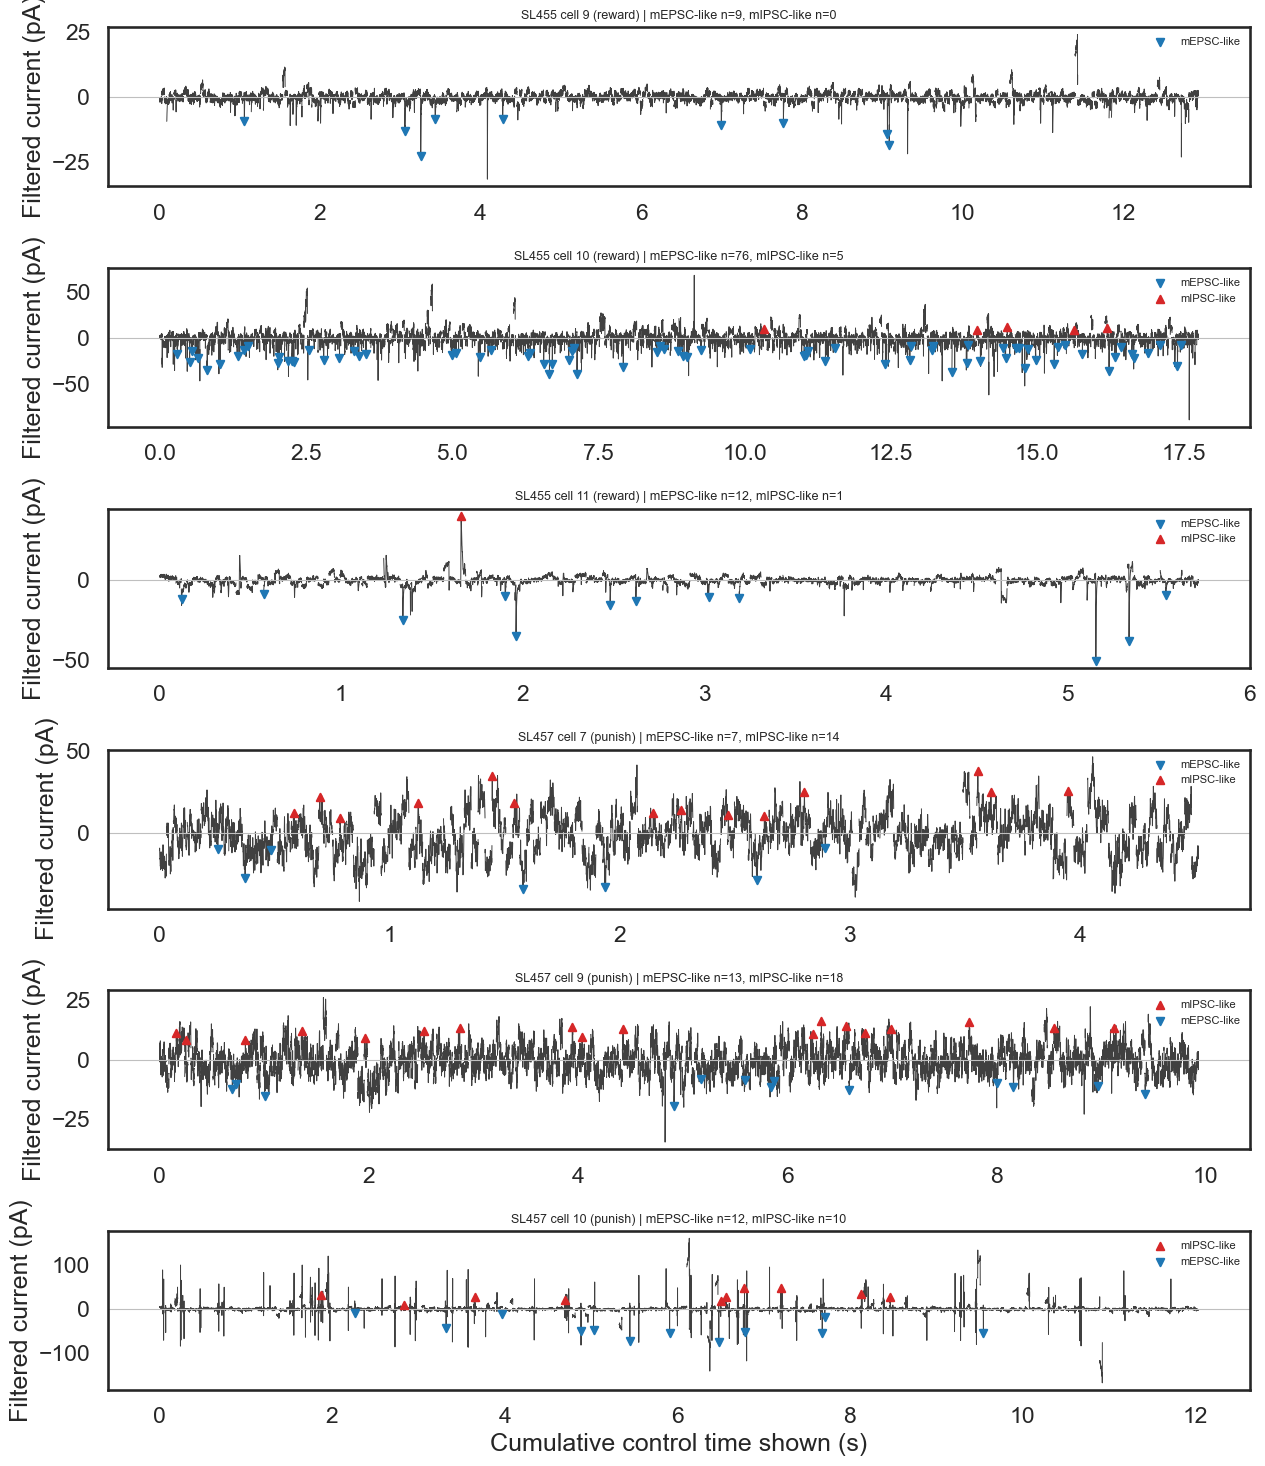

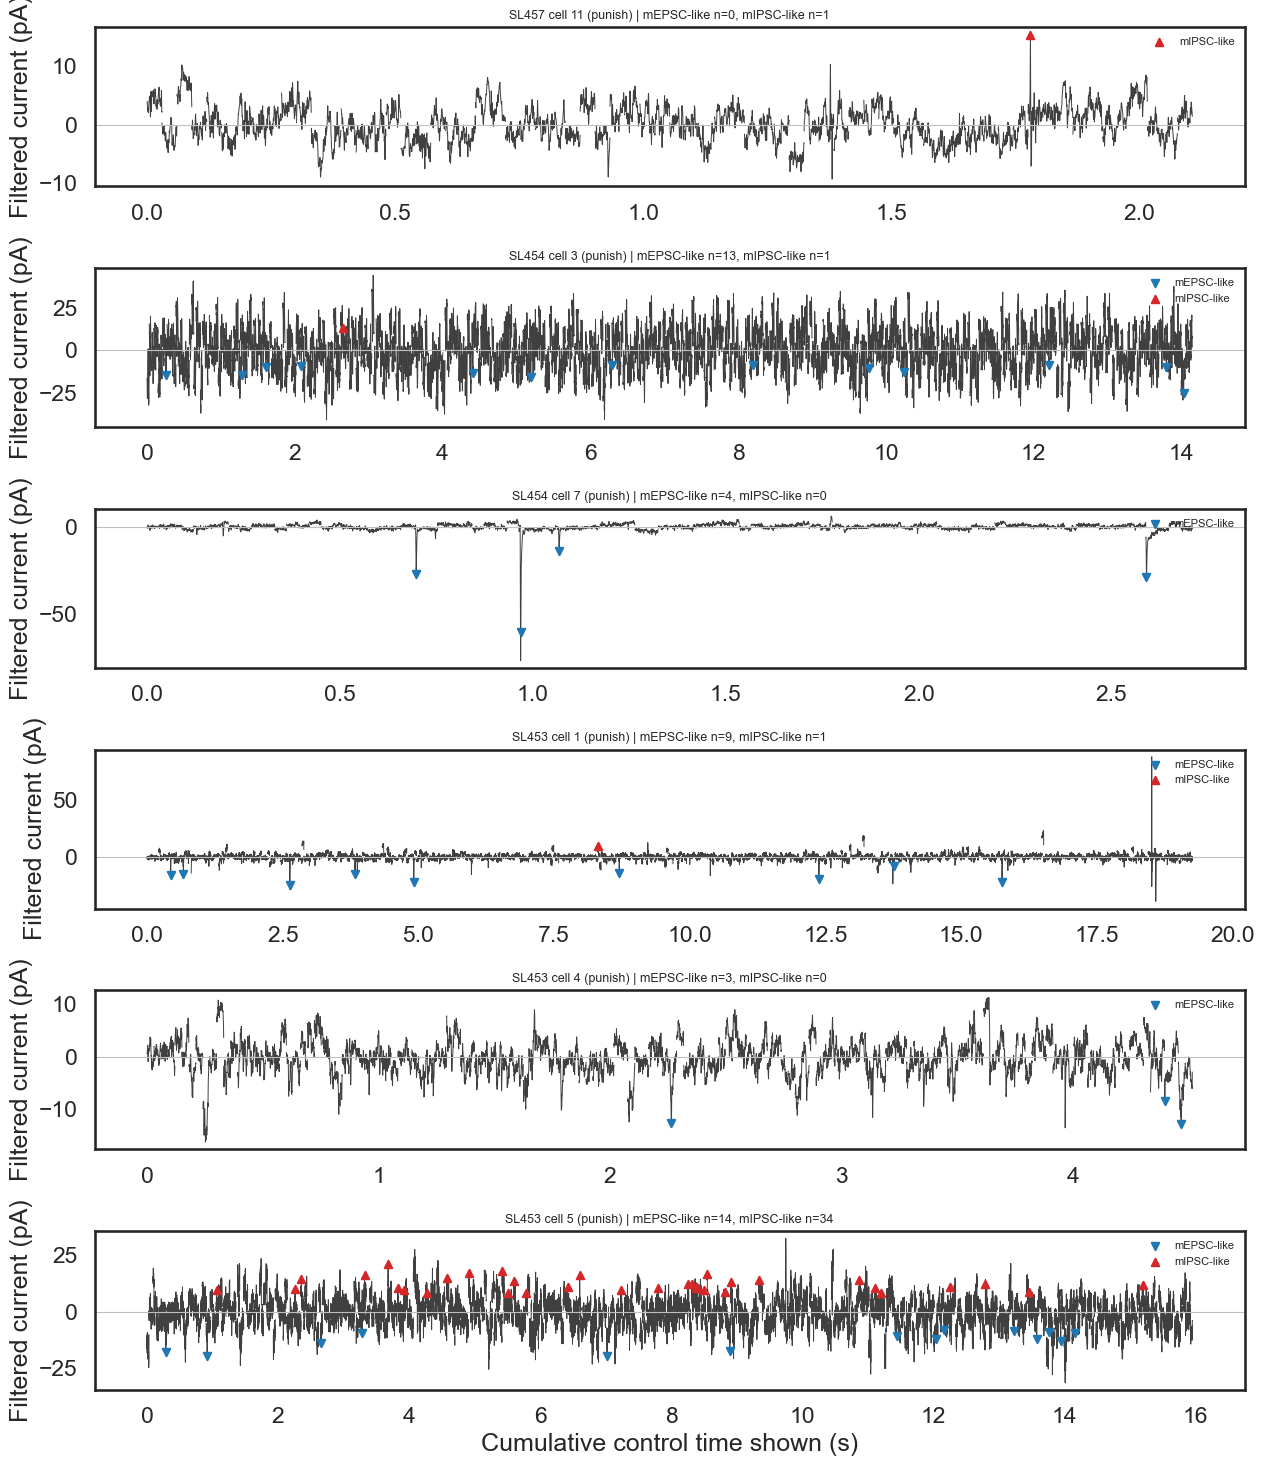

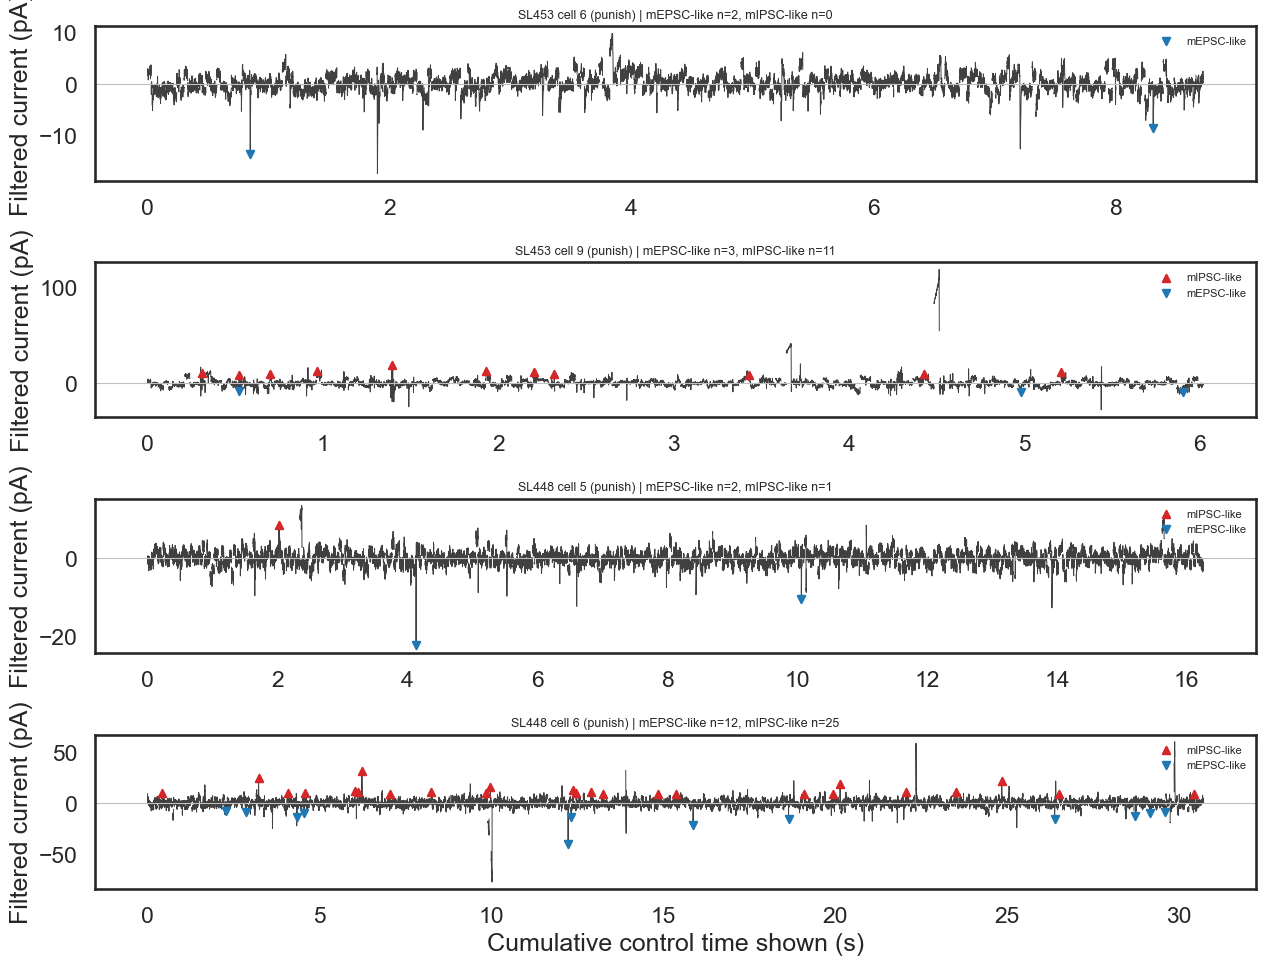

In [ ]:
display(mini_analysis_log_df)
if mini_comparison_df.empty:
    raise ValueError(
        "No cells had usable paired control traces. See mini_analysis_log_df."
    )
display(mini_comparison_df)

mini_validation_figures = plot_mini_detection_validation(
    control_trace_records,
    cells_per_figure=MINI_VALIDATION_CELLS_PER_FIGURE,
    max_seconds=MINI_VALIDATION_SECONDS,
)
plt.show()

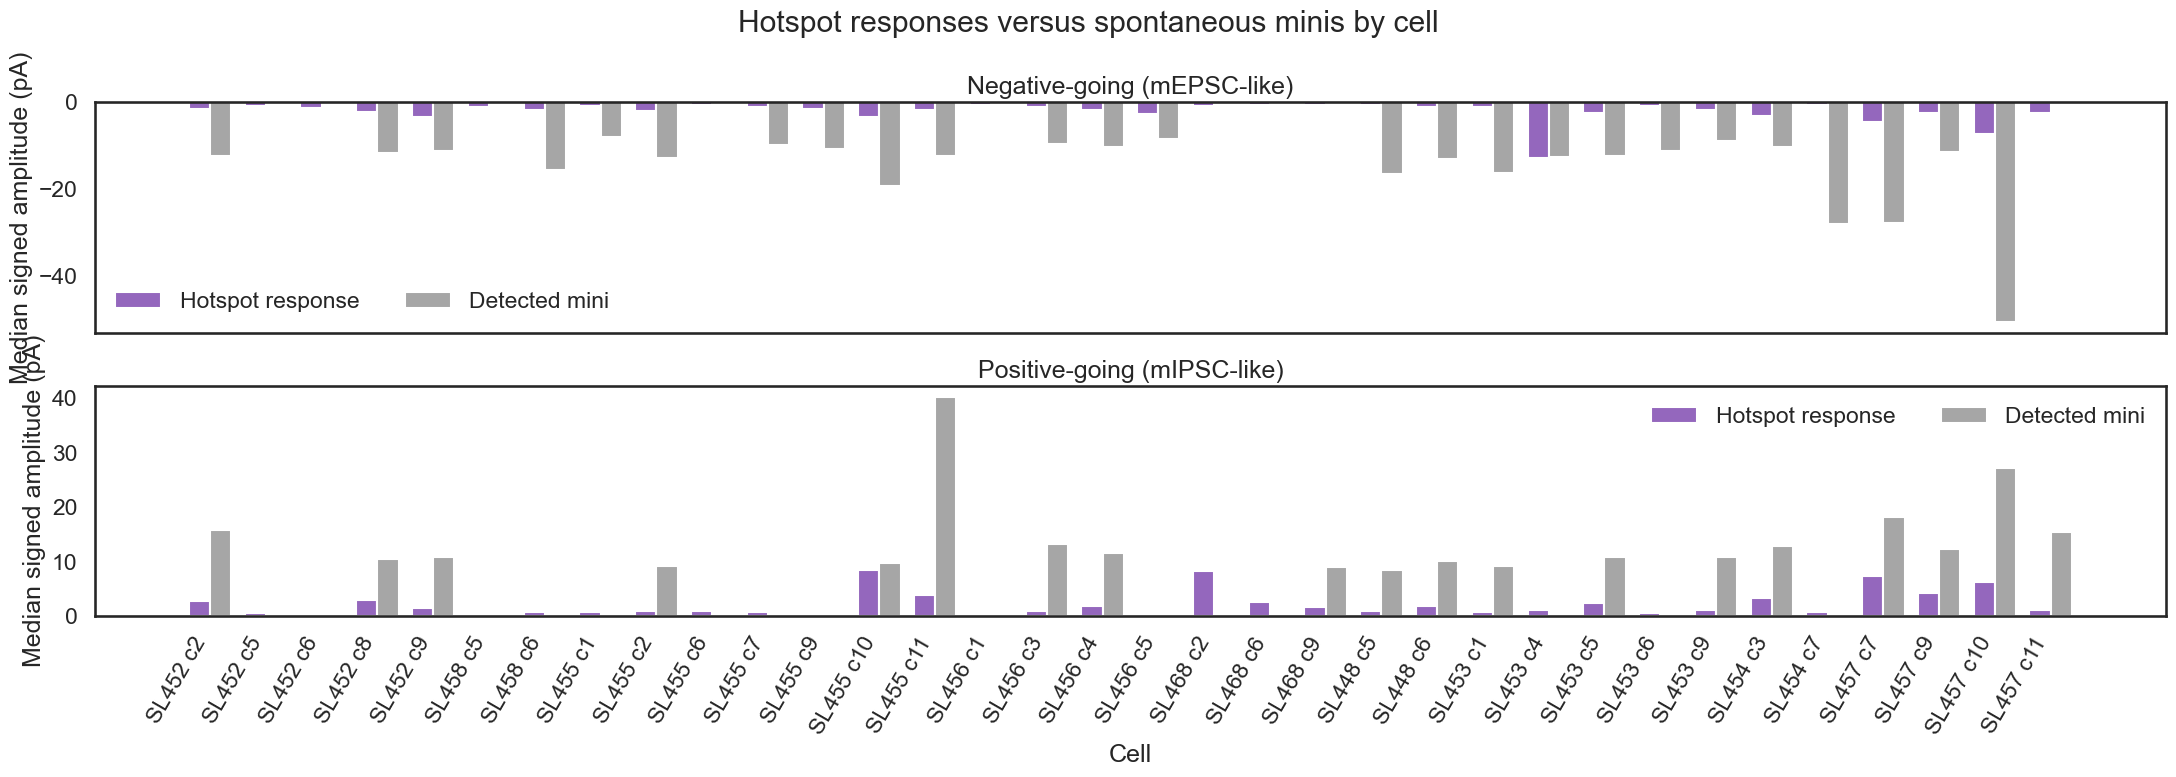

In [ ]:
# Cell-by-cell comparison of median signed hotspot and mini amplitudes.
mini_plot_df = mini_comparison_df.copy()
mini_plot_df["group"] = pd.Categorical(
    mini_plot_df["group"], categories=GROUP_ORDER, ordered=True
)
mini_plot_df = mini_plot_df.sort_values(
    ["group", "animal", "cell"]
).reset_index(drop=True)
x = np.arange(len(mini_plot_df), dtype=float)
labels = [
    f"{row.animal} c{row.cell}"
    for row in mini_plot_df.itertuples(index=False)
]
bar_width = 0.38
fig, axes = plt.subplots(
    2, 1, figsize=(max(12, 0.65 * len(mini_plot_df)), 8), sharex=True
)
for ax, hotspot_column, mini_column, title in (
    (axes[0], "hotspot_min_pa", "mini_min_pa", "Negative-going (mEPSC-like)"),
    (axes[1], "hotspot_max_pa", "mini_max_pa", "Positive-going (mIPSC-like)"),
):
    ax.bar(
        x - bar_width / 2, mini_plot_df[hotspot_column],
        width=bar_width, color="tab:purple", label="Hotspot response",
    )
    ax.bar(
        x + bar_width / 2, mini_plot_df[mini_column],
        width=bar_width, color="0.65", label="Detected mini",
    )
    ax.axhline(0, color="0.2", linewidth=0.8)
    ax.set_ylabel("Median signed amplitude (pA)")
    ax.set_title(title)
    ax.legend(frameon=False, ncol=2)
axes[1].set_xticks(x, labels, rotation=60, ha="right")
axes[1].set_xlabel("Cell")
fig.suptitle("Hotspot responses versus spontaneous minis by cell")
fig.tight_layout()
plt.show()


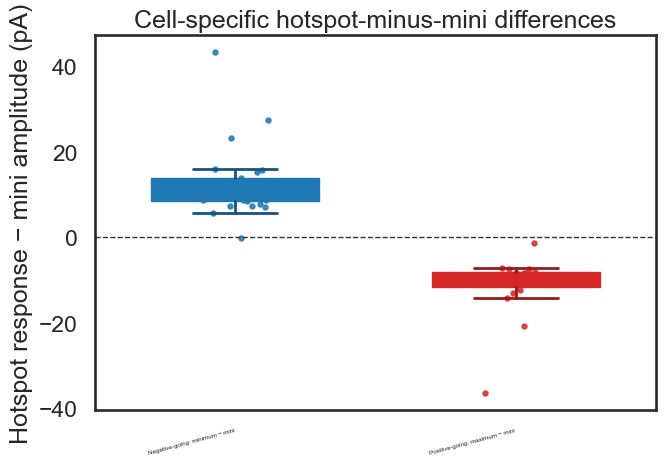

In [ ]:
# Distribution of the signed, cell-specific hotspot-minus-mini differences.
difference_groups = []
for column, label, color in (
    ("min_difference_pa", "Negative-going: minimum − mini", to_rgba("tab:blue")),
    ("max_difference_pa", "Positive-going: maximum − mini", to_rgba("tab:red")),
):
    values = pd.to_numeric(mini_comparison_df[column], errors="coerce")
    values = values[np.isfinite(values)].to_numpy(dtype=float)
    if len(values):
        difference_groups.append((values, label, color))

if not difference_groups:
    print("No cells have both hotspot and mini amplitudes to compare.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    ndap.plotScatterBar(
        [values for values, _, _ in difference_groups],
        labels=[label for _, label, _ in difference_groups],
        colors=[color for _, _, color in difference_groups],
        style="box", ax=ax,
    )
    ax.axhline(0, color="0.2", linestyle="--", linewidth=1)
    ax.set_ylabel("Hotspot response − mini amplitude (pA)")
    ax.set_title("Cell-specific hotspot-minus-mini differences")
    ax.tick_params(axis="x", rotation=15)
    fig.tight_layout()
    plt.show()

## 5. Fixed sign versus sign switching

This section separates two explanations for the active endpoint contrast: reward-to-punishment in task mode or dopamine-decrease-to-increase in dopamine mode. `COMPARISON_GROUPS` is selected automatically with `GROUPING_MODE`.

- **H1: fixed sign / magnitude change:** a hotspot retains its excitatory- or inhibitory-dominant identity, while condition can change $|x|$. For these unpaired data, the testable population-level implication is that the fraction on each side of zero is shared across conditions, while the conditional magnitude distributions may differ.
- **H2: sign switching / composition change:** condition changes the probability that a hotspot lies on each side of zero, and may also change $|x|$. A condition-specific sign fraction is consistent with sign switching or a change in population composition.

`ANALYSIS_WEIGHTING` controls the primary estimand throughout Section 5: `"animal_balanced"` gives every represented animal equal total weight, whereas `"pooled"` gives every hotspot equal weight. The default is animal-balanced. Whole-animal resampling and hierarchical validation preserve animal clustering under either setting.


### 5.1 Separate sign fraction from within-sign magnitude

#### What this analysis measures

This analysis separates **which side of zero a hotspot occupies** from **how strongly it occupies that side**. This prevents a change in the mean sign index from being interpreted as sign switching when it could instead reflect a magnitude change among already excitatory- or inhibitory-dominant hotspots.

#### Analysis steps

1. Keep finite hotspot sign values and classify each hotspot as excitatory-dominant ($x<-δ$), inhibitory-dominant ($x>δ$), or neutral ($|x|\leq\delta$).
2. Exclude neutral values from the two-sign comparison and calculate both pooled and animal-balanced inhibitory- and excitatory-dominant fractions for every condition.
3. Use the fraction selected by `ANALYSIS_WEIGHTING` as the primary estimate and retain the alternative as a sensitivity diagnostic.
4. Within each condition and sign class, summarize $|x|$ using sample size, animal count, mean, median, and interquartile range.
5. Plot the within-sign magnitude distributions with `plotScatterBar`. Pooled mode uses raw hotspots; animal-balanced mode gives every represented animal the same number of empirical-quantile points.

#### Expected result under each hypothesis

- **If H1 is true:** the selected excitatory/inhibitory fractions should be similar across conditions, but one or both conditional $|x|$ distributions may shift.
- **If H2 is true:** the fraction of sign should differ across conditions. Conditional magnitudes may also differ, so a joint change supports a mixture of switching/composition and amplitude effects.

This subsection is descriptive; uncertainty and model-based comparisons are added below.


,n_hotspots,n_animals,pooled_inhibitory_fraction,animal_balanced_inhibitory_fraction,between_animal_sd,pooled_excitatory_fraction,animal_balanced_excitatory_fraction,analysis_inhibitory_fraction,analysis_excitatory_fraction
group,,,,,,,,,
random,370,2,0.581081,0.486940,0.192422,0.418919,0.513060,0.486940,0.513060
reward,841,3,0.449465,0.542855,0.116882,0.550535,0.457145,0.542855,0.457145
punish,488,4,0.536885,0.540844,0.134864,0.463115,0.459156,0.540844,0.459156


,group,dominance,n_hotspots,n_animals,median_magnitude,mean_magnitude,q25,q75
0,punish,excitatory-dominant,226,4,1.0,1.0,1.0,1.0
1,punish,inhibitory-dominant,262,4,1.0,1.0,1.0,1.0
2,random,excitatory-dominant,155,2,1.0,1.0,1.0,1.0
3,random,inhibitory-dominant,215,2,1.0,1.0,1.0,1.0
4,reward,excitatory-dominant,463,3,1.0,1.0,1.0,1.0
5,reward,inhibitory-dominant,378,3,1.0,1.0,1.0,1.0


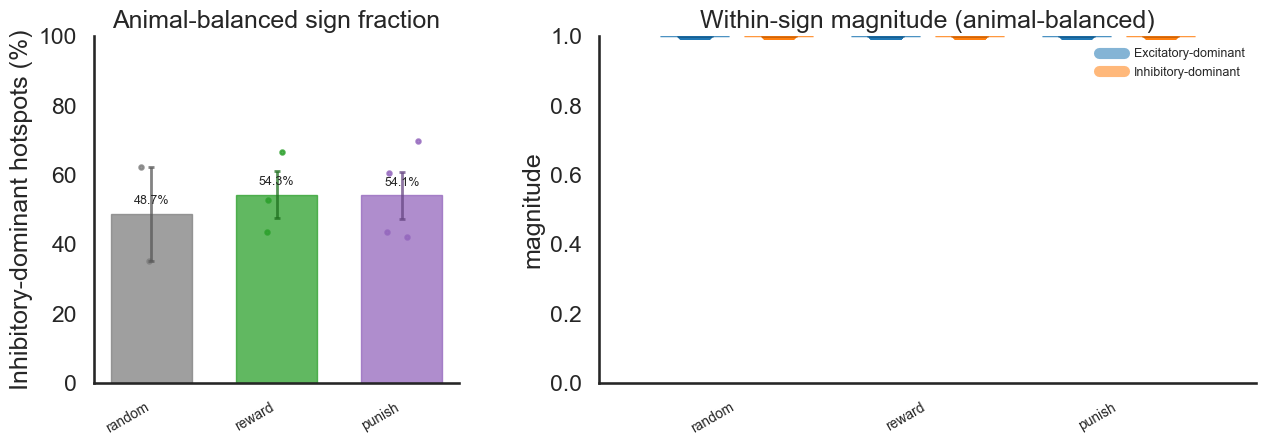

In [ ]:
from itertools import combinations, permutations
from math import comb

from scipy.optimize import linprog, minimize
from scipy.sparse import lil_matrix
from scipy.special import betaln, expit, gammaln
from scipy.stats import wasserstein_distance


# Values in [-SIGN_EPSILON, +SIGN_EPSILON] are treated as neutral. Keep this
# at zero for the primary analysis; changing it to 0.005 performs the proposed
# sensitivity analysis without changing any code below.
SIGN_EPSILON = 0.005


VALID_ANALYSIS_WEIGHTINGS = {"animal_balanced", "pooled"}
ANALYSIS_WEIGHTING = str(ANALYSIS_WEIGHTING).strip().lower()
if ANALYSIS_WEIGHTING not in VALID_ANALYSIS_WEIGHTINGS:
    raise ValueError(
        "ANALYSIS_WEIGHTING must be 'animal_balanced' or 'pooled'."
    )
WEIGHTING_LABEL = (
    "Animal-balanced"
    if ANALYSIS_WEIGHTING == "animal_balanced"
    else "Pooled"
)


def analysis_weights(frame, weighting=ANALYSIS_WEIGHTING):
    """Return normalized hotspot weights for the selected estimand."""
    if frame.empty:
        return np.array([], dtype=float)
    if weighting == "pooled":
        return np.full(len(frame), 1.0 / len(frame))
    counts = frame.groupby("animal", observed=True)["animal"].transform("size")
    weights = 1.0 / counts.to_numpy(dtype=float)
    return weights / weights.sum()


def weighted_quantile(values, quantiles, weights):
    """Calculate weighted quantiles using centered empirical mass."""
    values = np.asarray(values, dtype=float)
    quantiles = np.atleast_1d(quantiles).astype(float)
    weights = np.asarray(weights, dtype=float)
    finite = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not finite.any():
        return np.full(len(quantiles), np.nan)
    values = values[finite]
    weights = weights[finite]
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = (np.cumsum(weights) - 0.5 * weights) / weights.sum()
    return np.interp(quantiles, cumulative, values)


def prepare_sign_analysis_data(hotspot_df, epsilon=SIGN_EPSILON):
    """Return finite hotspot signs with explicit biological sign labels."""
    required = {"group", "animal", "hotspot_sign"}
    missing = required.difference(hotspot_df.columns)
    if missing:
        raise ValueError(f"hotspot_df is missing columns: {sorted(missing)}")

    data = hotspot_df.loc[
        hotspot_df["group"].isin(GROUP_ORDER),
        ["group", "animal", "cell", "hotspot_sign"],
    ].copy()
    data["hotspot_sign"] = pd.to_numeric(data["hotspot_sign"], errors="coerce")
    data = data[np.isfinite(data["hotspot_sign"])].copy()
    data["dominance"] = np.select(
        [
            data["hotspot_sign"] < -epsilon,
            data["hotspot_sign"] > epsilon,
        ],
        ["excitatory-dominant", "inhibitory-dominant"],
        default="neutral",
    )
    data["magnitude"] = data["hotspot_sign"].abs()
    return data


sign_analysis_df = prepare_sign_analysis_data(hotspot_sign_df)
decisive_sign_df = sign_analysis_df[
    sign_analysis_df["dominance"] != "neutral"
].copy()
if decisive_sign_df.empty:
    raise ValueError("No non-neutral hotspot signs are available for Section 5.")

# Keep both summaries; ANALYSIS_WEIGHTING selects the primary one below.
animal_sign_fraction_df = (
    decisive_sign_df.assign(
        is_inhibitory=lambda frame: (
            frame["dominance"] == "inhibitory-dominant"
        ).astype(float)
    )
    .groupby(["group", "animal"], observed=True)
    .agg(
        n_hotspots=("hotspot_sign", "size"),
        n_inhibitory=("is_inhibitory", "sum"),
        inhibitory_fraction=("is_inhibitory", "mean"),
    )
    .reset_index()
)
animal_sign_fraction_df["excitatory_fraction"] = (
    1.0 - animal_sign_fraction_df["inhibitory_fraction"]
)

pooled_sign_summary = (
    decisive_sign_df.assign(
        is_inhibitory=lambda frame: (
            frame["dominance"] == "inhibitory-dominant"
        ).astype(float)
    )
    .groupby("group", observed=True)
    .agg(
        n_hotspots=("hotspot_sign", "size"),
        n_animals=("animal", "nunique"),
        pooled_inhibitory_fraction=("is_inhibitory", "mean"),
    )
)
balanced_sign_summary = (
    animal_sign_fraction_df.groupby("group", observed=True)
    .agg(
        animal_balanced_inhibitory_fraction=("inhibitory_fraction", "mean"),
        between_animal_sd=("inhibitory_fraction", "std"),
    )
)
sign_fraction_summary_df = pooled_sign_summary.join(balanced_sign_summary)
sign_fraction_summary_df["pooled_excitatory_fraction"] = (
    1.0 - sign_fraction_summary_df["pooled_inhibitory_fraction"]
)
sign_fraction_summary_df["animal_balanced_excitatory_fraction"] = (
    1.0 - sign_fraction_summary_df["animal_balanced_inhibitory_fraction"]
)
sign_fraction_summary_df = sign_fraction_summary_df.reindex(GROUP_ORDER)

fraction_column = (
    "animal_balanced_inhibitory_fraction"
    if ANALYSIS_WEIGHTING == "animal_balanced"
    else "pooled_inhibitory_fraction"
)
sign_fraction_summary_df["analysis_inhibitory_fraction"] = (
    sign_fraction_summary_df[fraction_column]
)
sign_fraction_summary_df["analysis_excitatory_fraction"] = (
    1.0 - sign_fraction_summary_df["analysis_inhibitory_fraction"]
)

magnitude_records = []
for (group, dominance), rows in decisive_sign_df.groupby(
    ["group", "dominance"], observed=True
):
    weights = analysis_weights(rows)
    values = rows["magnitude"].to_numpy(dtype=float)
    q25, median, q75 = weighted_quantile(
        values, [0.25, 0.5, 0.75], weights
    )
    magnitude_records.append({
        "group": group,
        "dominance": dominance,
        "n_hotspots": len(rows),
        "n_animals": rows["animal"].nunique(),
        "median_magnitude": median,
        "mean_magnitude": np.average(values, weights=weights),
        "q25": q25,
        "q75": q75,
    })
magnitude_summary_df = pd.DataFrame(magnitude_records)

display(sign_fraction_summary_df)
display(magnitude_summary_df)

underrepresented_groups = sign_fraction_summary_df.index[
    sign_fraction_summary_df["n_animals"] < 2
].tolist()
if underrepresented_groups:
    print(
        "Caution: fewer than two animals contributed valid hotspots for "
        f"{underrepresented_groups}. Their Section 5 results are descriptive "
        "and cannot estimate between-animal uncertainty."
    )

fig, (ax_fraction, ax_magnitude) = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    gridspec_kw={"width_ratios": [1, 1.8]},
)

# Panel 1: primary inhibitory-dominant fraction. Animal-level fractions
# are overlaid as diagnostics but do not determine the bar height.
group_positions = np.arange(len(GROUP_ORDER), dtype=float)
inhibitory_percent = (
    100
    * sign_fraction_summary_df.loc[
        GROUP_ORDER, "analysis_inhibitory_fraction"
    ].to_numpy(dtype=float)
)
bar_width = 0.65
fraction_distributions = []
for group in GROUP_ORDER:
    if ANALYSIS_WEIGHTING == "animal_balanced":
        values = animal_sign_fraction_df.loc[
            animal_sign_fraction_df["group"] == group,
            "inhibitory_fraction",
        ].to_numpy(dtype=float)
    else:
        values = (
            decisive_sign_df.loc[
                decisive_sign_df["group"] == group, "dominance"
            ]
            .eq("inhibitory-dominant")
            .to_numpy(dtype=float)
        )
    fraction_distributions.append(100 * values)
ndap.plotScatterBar(
    fraction_distributions,
    labels=GROUP_ORDER,
    style="bar",
    ax=ax_fraction,
    colors=[
        to_rgba(GROUP_COLORS[group], alpha=0.75) for group in GROUP_ORDER
    ],
    positions=group_positions,
    width=bar_width,
)
bars = ax_fraction.patches
for bar, value in zip(bars, inhibitory_percent):
    ax_fraction.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax_fraction.set_xticks(
    group_positions, GROUP_ORDER, rotation=30, ha="right",
    fontsize=GROUP_LABEL_FONTSIZE,
)
ax_fraction.set_ylabel("Inhibitory-dominant hotspots (%)")
ax_fraction.set_ylim(0, 100)
ax_fraction.set_title(f"{WEIGHTING_LABEL} sign fraction")
for spine in ("top", "right"):
    ax_fraction.spines[spine].set_visible(False)

# Panel 2: within-sign magnitude. Fixed offsets and widths keep every
# excitatory/inhibitory box the same size.
def magnitude_plot_values(rows):
    """Prepare an unweighted array for plotScatterBar."""
    if ANALYSIS_WEIGHTING == "pooled":
        return rows["magnitude"].to_numpy(dtype=float)

    animal_values = [
        animal_rows["magnitude"].to_numpy(dtype=float)
        for _, animal_rows in rows.groupby("animal", observed=True)
    ]
    points_per_animal = max(map(len, animal_values))
    quantiles = np.linspace(0, 1, points_per_animal)
    return np.concatenate([
        np.quantile(values, quantiles) for values in animal_values
    ])


dominance_order = ["excitatory-dominant", "inhibitory-dominant"]
dominance_colors = {
    "excitatory-dominant": "tab:blue",
    "inhibitory-dominant": "tab:orange",
}
box_offsets = [-0.22, 0.22]
box_width = 0.36
positions, distributions, colors = [], [], []
for group_index, group in enumerate(GROUP_ORDER):
    for sign_index, dominance in enumerate(dominance_order):
        rows = decisive_sign_df.loc[
            (decisive_sign_df["group"] == group)
            & (decisive_sign_df["dominance"] == dominance)
        ]
        values = magnitude_plot_values(rows) if len(rows) else np.array([])
        if len(values):
            positions.append(group_index + box_offsets[sign_index])
            distributions.append(values)
            colors.append(to_rgba(dominance_colors[dominance], alpha=0.55))

ndap.plotScatterBar(
    distributions,
    style="box",
    ax=ax_magnitude,
    colors=colors,
    positions=positions,
    width=box_width,
    scatter_alpha=0.6,
)
ax_magnitude.plot(
    [], [], color="tab:blue", linewidth=8, alpha=0.55,
    label="Excitatory-dominant",
)
ax_magnitude.plot(
    [], [], color="tab:orange", linewidth=8, alpha=0.55,
    label="Inhibitory-dominant",
)
ax_magnitude.set_xticks(
    group_positions, GROUP_ORDER, rotation=30, ha="right",
    fontsize=GROUP_LABEL_FONTSIZE,
)
ax_magnitude.set_ylabel("magnitude")
ax_magnitude.set_ylim(0, 1)
ax_magnitude.set_title(f"Within-sign magnitude ({WEIGHTING_LABEL.lower()})")
ax_magnitude.legend(frameon=False, fontsize=9)
for spine in ("top", "right"):
    ax_magnitude.spines[spine].set_visible(False)

fig.tight_layout(w_pad=2.5)
plt.show()


### 5.2 Minimum and maximum sign-switch mass

#### What this analysis measures

The baseline and comparison hotspots are unpaired, so an exact switch fraction is not identifiable. However, their inhibitory-dominant probabilities under the selected `ANALYSIS_WEIGHTING` constrain the fraction that would have different signs under any possible coupling of the two marginal distributions. These are the Fréchet bounds on sign disagreement.

Let $p_B=P_{baseline}(x>0)$ and $p_C=P_{comparison}(x>0)$. Then

$$
S_{switch,min}=|p_C-p_B|
$$

and

$$
S_{switch,max}=1-|p_B+p_C-1|.
$$

The lower bound is the probability mass that **must** cross zero to reconcile the two sign proportions. The upper bound is the largest sign disagreement compatible with those marginals; it is not an estimate of the actual switch rate.

#### Analysis steps

1. Calculate inhibitory-dominant fractions for `BASELINE_GROUP` and `COMPARISON_GROUP` using the selected weighting.
2. Use those fractions as $p_B$ and $p_C$. With animal balancing, each animal has equal total weight; with pooling, contribution is proportional to hotspot count.
3. Calculate $S_{switch,min}$ and $S_{switch,max}$ from the equations above.
4. If both comparison groups contain at least two contributing animals, resample whole animals within condition 10,000 times and report cluster-bootstrap intervals for both bounds. Otherwise, report only the descriptive bounds.

#### Expected result under each hypothesis

- **If H1 is true:** $p_B$ and $p_C$ should be similar, so $S_{switch,min}$ should be near zero within animal-level uncertainty.
- **If H2 is true:** a clearly positive $S_{switch,min}$ indicates that some cross-zero population mass is required. A large lower bound is stronger distribution-level evidence for switching/composition change.

These bounds do not reveal which hotspots switched or the direction of individual transitions.


In [ ]:
def switch_fraction_bounds(p_positive_a, p_positive_b):
    """Fréchet bounds on sign disagreement from two positive marginals."""
    p_positive_a = float(p_positive_a)
    p_positive_b = float(p_positive_b)
    lower = abs(p_positive_b - p_positive_a)
    upper = 1.0 - abs(p_positive_a + p_positive_b - 1.0)
    return lower, upper


def bootstrap_switch_bounds(
    animal_fraction_df, n_bootstrap=10_000, seed=2026
):
    """Cluster-bootstrap selected-weighting bounds by animal."""
    counts = {
        group: animal_fraction_df.loc[
            animal_fraction_df["group"] == group,
            ["n_hotspots", "n_inhibitory", "inhibitory_fraction"],
        ].to_numpy(dtype=float)
        for group in COMPARISON_GROUPS
    }
    if any(len(values) == 0 for values in counts.values()):
        raise ValueError(
            f"{BASELINE_GROUP} and {COMPARISON_GROUP} must each "
            "contain at least one animal."
        )

    rng = np.random.default_rng(seed)
    samples = np.empty((n_bootstrap, 2), dtype=float)
    for index in range(n_bootstrap):
        fractions = {}
        for group, group_counts in counts.items():
            sampled = group_counts[
                rng.integers(0, len(group_counts), size=len(group_counts))
            ]
            if ANALYSIS_WEIGHTING == "animal_balanced":
                fractions[group] = sampled[:, 2].mean()
            else:
                fractions[group] = sampled[:, 1].sum() / sampled[:, 0].sum()
        samples[index] = switch_fraction_bounds(
            fractions[BASELINE_GROUP], fractions[COMPARISON_GROUP]
        )
    return samples


p_inhibitory = sign_fraction_summary_df["analysis_inhibitory_fraction"]
switch_min, switch_max = switch_fraction_bounds(
    p_inhibitory[BASELINE_GROUP], p_inhibitory[COMPARISON_GROUP]
)
comparison_animal_counts = animal_sign_fraction_df.groupby(
    "group", observed=True
)["animal"].nunique()
bootstrap_is_estimable = all(
    comparison_animal_counts.get(group, 0) >= 2
    for group in COMPARISON_GROUPS
)
if bootstrap_is_estimable:
    switch_bound_samples = bootstrap_switch_bounds(
        animal_sign_fraction_df
    )
    lower_ci = np.percentile(switch_bound_samples, 2.5, axis=0)
    upper_ci = np.percentile(switch_bound_samples, 97.5, axis=0)
else:
    switch_bound_samples = np.empty((0, 2))
    lower_ci = np.repeat(np.nan, 2)
    upper_ci = np.repeat(np.nan, 2)
switch_bounds_df = pd.DataFrame(
    {
        "estimate": [switch_min, switch_max],
        "cluster-bootstrap 2.5%": lower_ci,
        "cluster-bootstrap 97.5%": upper_ci,
    },
    index=["minimum sign-switch mass", "maximum sign-switch mass"],
)

display(
    pd.Series(
        {
            f"{BASELINE_GROUP} P(inhibitory-dominant)": (
                p_inhibitory[BASELINE_GROUP]
            ),
            f"{COMPARISON_GROUP} P(inhibitory-dominant)": (
                p_inhibitory[COMPARISON_GROUP]
            ),
        },
        name=f"{WEIGHTING_LABEL.lower()} estimate",
    ).to_frame()
)
display(switch_bounds_df)
if not bootstrap_is_estimable:
    print(
        "Cluster-bootstrap intervals are not reported because "
        f"{BASELINE_GROUP} and {COMPARISON_GROUP} must each have at "
        "least two contributing animals."
    )
print(
    "These are coupling bounds implied by unpaired marginal distributions; "
    "they do not identify which individual hotspots switched sign."
)


,animal-balanced estimate
reward P(inhibitory-dominant),0.542855
punish P(inhibitory-dominant),0.540844


,estimate,cluster-bootstrap 2.5%,cluster-bootstrap 97.5%
minimum sign-switch mass,0.002011,0.002011,0.176198
maximum sign-switch mass,0.916300,0.750305,0.994632


These are coupling bounds implied by unpaired marginal distributions; they do not identify which individual hotspots switched sign.


### 5.3 Sign-constrained optimal transport

#### What this analysis measures

Optimal transport asks how baseline probability mass must be reassigned to reproduce the comparison distribution. It provides a distribution-level comparison between a strict sign-fixed explanation, where transport across zero is forbidden, and a sign-switching explanation, where cross-zero transport is allowed.

For source bin $x_i$ and target bin $x_j$, the implemented cost is

$$
C(x_i,x_j)=|x_i-x_j|^2+\lambda\,I[\operatorname{sign}(x_i)\neq\operatorname{sign}(x_j)].
$$

where $|x_i-x_j|^2$ says "moving further is more expensive" and $\lambda\,I[\operatorname{sign}(x_i)\neq\operatorname{sign}(x_j)]$ determines the extra price to cross zero

#### Analysis steps

1. Convert the weighted baseline and comparison hotspot distributions into 80 common bins spanning $[-1,1]$ (bin width $0.025$).
2. Solve balanced transport with cross-zero entries fixed to zero. This strict sign-fixed problem is feasible only when the two groups have exactly the same total mass on each side of zero.
3. Solve unconstrained transport with $\lambda=0$ and report its squared movement cost and cross-zero mass.
4. Repeat over increasing $\lambda$ values. For each solution, separate the squared movement cost, cross-zero mass, and total penalized objective.
5. Plot how movement cost and cross-zero mass change as switching becomes increasingly expensive.

#### Expected result under each hypothesis

- **If H1 is true:** strict sign-fixed transport should be feasible, and allowing cross-zero movement should provide little improvement. The optimal cross-zero mass should fall to zero with a modest penalty, while remaining differences are explained by movement within each sign.
- **If H2 is true:** strict sign-fixed transport is infeasible when sign proportions differ, or unconstrained transport obtains a much better explanation by moving appreciable mass across zero. Cross-zero mass that persists even for large $\lambda$ reflects mass forced by the marginal sign imbalance; its minimum is linked to Section 5.2's lower bound.

,model,feasible,squared movement cost,cross-zero mass,message
0,strict sign-fixed (crossing forbidden),False,inf,NaN,The problem is infeasible. (HiGHS Status 8: mo...
1,unconstrained sign-switch (lambda=0),True,0.007843,0.002011,optimal balanced transport


,lambda,squared movement cost,cross-zero mass,penalized objective
0,0.000,0.007843,0.002011,0.007843
1,0.001,0.007843,0.002011,0.007845
2,0.010,0.007843,0.002011,0.007863
3,0.100,0.007843,0.002011,0.008044
4,1.000,0.007843,0.002011,0.009854
5,10.000,0.007843,0.002011,0.027951
6,100.000,0.007843,0.002011,0.208919


Strict sign-fixed transport is infeasible because reward and punish contain different mass on the two sides of zero. The minimum cross-zero mass is therefore constrained by Section 5.2's lower bound.


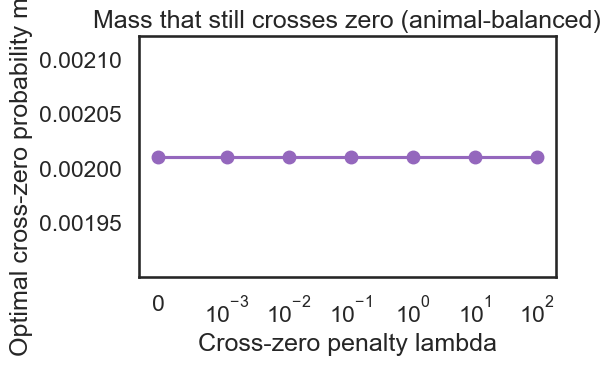

In [ ]:
def weighted_hotspot_histogram(frame, group, bin_edges):
    """Discretize one condition using ANALYSIS_WEIGHTING."""
    rows = frame[frame["group"] == group]
    if rows.empty:
        raise ValueError(f"No observations for {group}.")
    mass, _ = np.histogram(
        rows["hotspot_sign"],
        bins=bin_edges,
        weights=analysis_weights(rows),
    )
    mass = mass.astype(float)
    mass /= mass.sum()
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    keep = mass > 0
    return centers[keep], mass[keep]


def solve_sign_penalized_transport(
    source_x,
    source_mass,
    target_x,
    target_mass,
    crossing_penalty=0.0,
    forbid_crossing=False,
):
    """Solve balanced discrete OT with squared movement and sign penalty."""
    source_x = np.asarray(source_x, dtype=float)
    target_x = np.asarray(target_x, dtype=float)
    source_mass = np.asarray(source_mass, dtype=float)
    target_mass = np.asarray(target_mass, dtype=float)
    source_mass = source_mass / source_mass.sum()
    target_mass = target_mass / target_mass.sum()

    n_source, n_target = len(source_x), len(target_x)
    movement_cost = (source_x[:, None] - target_x[None, :]) ** 2
    crossing = np.signbit(source_x[:, None]) != np.signbit(target_x[None, :])
    objective = movement_cost + crossing_penalty * crossing

    # The final target constraint is redundant because both marginals sum to 1.
    constraints = lil_matrix(
        (n_source + n_target - 1, n_source * n_target), dtype=float
    )
    for source_index in range(n_source):
        start = source_index * n_target
        constraints[source_index, start : start + n_target] = 1.0
    for target_index in range(n_target - 1):
        constraints[
            n_source + target_index, target_index::n_target
        ] = 1.0
    constraint_values = np.concatenate([source_mass, target_mass[:-1]])

    if forbid_crossing:
        bounds = [
            (0.0, 0.0) if is_crossing else (0.0, None)
            for is_crossing in crossing.ravel()
        ]
    else:
        bounds = (0.0, None)

    result = linprog(
        objective.ravel(),
        A_eq=constraints.tocsr(),
        b_eq=constraint_values,
        bounds=bounds,
        method="highs",
    )
    if not result.success:
        return {
            "success": False,
            "message": result.message,
            "movement_cost": np.inf,
            "cross_zero_mass": np.nan,
            "penalized_cost": np.inf,
        }

    plan = result.x.reshape(n_source, n_target)
    cross_zero_mass = float(plan[crossing].sum())
    squared_movement = float(np.sum(plan * movement_cost))
    return {
        "success": True,
        "message": result.message,
        "movement_cost": squared_movement,
        "cross_zero_mass": cross_zero_mass,
        "penalized_cost": squared_movement + crossing_penalty * cross_zero_mass,
    }


# Binning keeps the transport program small and makes all lambda values use the
# same empirical support. Eighty bins preserve 0.025 sign-index resolution.
TRANSPORT_BIN_EDGES = np.linspace(-1.0, 1.0, 81)
baseline_x, baseline_mass = weighted_hotspot_histogram(
    decisive_sign_df, BASELINE_GROUP, TRANSPORT_BIN_EDGES
)
comparison_x, comparison_mass = weighted_hotspot_histogram(
    decisive_sign_df, COMPARISON_GROUP, TRANSPORT_BIN_EDGES
)

strict_transport = solve_sign_penalized_transport(
    baseline_x,
    baseline_mass,
    comparison_x,
    comparison_mass,
    forbid_crossing=True,
)
transport_lambdas = np.array([0.0, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0])
transport_records = []
for penalty in transport_lambdas:
    solution = solve_sign_penalized_transport(
        baseline_x,
        baseline_mass,
        comparison_x,
        comparison_mass,
        crossing_penalty=penalty,
    )
    transport_records.append(
        {
            "lambda": penalty,
            "squared movement cost": solution["movement_cost"],
            "cross-zero mass": solution["cross_zero_mass"],
            "penalized objective": solution["penalized_cost"],
        }
    )
transport_df = pd.DataFrame(transport_records)

strict_summary_df = pd.DataFrame(
    [
        {
            "model": "strict sign-fixed (crossing forbidden)",
            "feasible": strict_transport["success"],
            "squared movement cost": strict_transport["movement_cost"],
            "cross-zero mass": strict_transport["cross_zero_mass"],
            "message": strict_transport["message"],
        },
        {
            "model": "unconstrained sign-switch (lambda=0)",
            "feasible": True,
            "squared movement cost": transport_df.iloc[0][
                "squared movement cost"
            ],
            "cross-zero mass": transport_df.iloc[0]["cross-zero mass"],
            "message": "optimal balanced transport",
        },
    ]
)
display(strict_summary_df)
display(transport_df)

if not strict_transport["success"]:
    print(
        "Strict sign-fixed transport is infeasible because "
        f"{BASELINE_GROUP} and {COMPARISON_GROUP} contain different "
        "mass on the two sides of zero. The minimum "
        "cross-zero mass is therefore constrained by Section 5.2's lower bound."
    )

fig, ax_mass = plt.subplots(figsize=(6, 4))
ax_mass.plot(
    transport_df["lambda"],
    transport_df["cross-zero mass"],
    marker="o",
    color="tab:purple",
)
ax_mass.set_xscale("symlog", linthresh=1e-3)
ax_mass.set_xlabel("Cross-zero penalty lambda")
ax_mass.set_ylabel("Optimal cross-zero probability mass")
ax_mass.set_title(
    f"Mass that still crosses zero ({WEIGHTING_LABEL.lower()})"
)
fig.tight_layout()
plt.show()


### 5.4 Population model fitting and validation

#### What this analysis measures

This subsection makes the H1-versus-H2 comparison explicit at the animal level. Because hotspots are unpaired across conditions, the identifiable comparison is between a model with one shared population sign probability and a model with condition-specific sign probabilities—not a model that estimates individual $-\rightarrow+$ or $+\rightarrow-$ transition rates.

- **H1 model:** all active groups share one $p_I=P(x>0)$.
- **H2 model:** each active group has a separate $p_I$ value.

Both models use the same condition- and sign-specific magnitude distributions, so their predictive-performance difference isolates the sign-composition component.

#### Analysis steps

1. For each animal, count the number of inhibitory-dominant hotspots $k_a$ among $n_a$ decisive hotspots.
2. Fit H1 and H2 with a beta-binomial likelihood. This treats the animal as the replicate and uses a shared concentration parameter to allow more between-animal variation than a simple binomial model.
3. Obtain regularized maximum-a-posteriori estimates using weak priors on the sign logits and concentration. Approximate parameter uncertainty with the inverse-Hessian (Laplace) covariance.
4. Fit logit-normal magnitude distributions separately for each condition and observed sign using `ANALYSIS_WEIGHTING`.
5. Generate 2,000 approximate posterior-predictive experiments with the observed number of hotspots per animal. Aggregate simulated outcomes with the selected weighting and compare observed and predictive intervals for $P(x>0)$, $E[x]$, $E(|x|\mid x<0)$, and $E(|x|\mid x>0)$.
6. Plot the predictive distribution of the comparison-minus-baseline inhibitory fraction under both models and mark the observed value.
7. When every condition has at least two contributing animals, perform leave-one-animal-out refitting and compare sign expected log predictive density (ELPD). If holding out an animal would remove its condition from training, report the comparison as not estimable.

#### Expected result under each hypothesis

- **If H1 is true:** the shared-sign model should reproduce each condition's sign fraction and the active endpoint difference. H2 should provide little or no out-of-animal predictive gain, so $\Delta\mathrm{ELPD}=\mathrm{ELPD}_{H2}-\mathrm{ELPD}_{H1}$ should be near zero or negative.
- **If H2 is true:** the observed condition-specific sign fractions—especially the active endpoint difference—should fall poorly within H1 predictions but be reproduced by H2. With enough animals, H2 should have positive leave-one-animal-out $\Delta\mathrm{ELPD}$.
- **If both sign and magnitude change:** H2 improves sign prediction, while the conditional magnitude summaries also differ across conditions.

Posterior-predictive fit alone asks whether a model can generate data like those observed; leave-one-animal-out ELPD asks whether the added condition-specific sign parameters improve prediction. Neither identifies directional switching rates without paired hotspots or additional mechanistic constraints.


In [ ]:
# This is the identifiable population-level H1-vs-H2 comparison for unpaired
# hotspots. H1 has one shared sign probability; H2 has one per condition. A
# beta-binomial likelihood makes the animal, rather than the hotspot, the unit
# of replication and allows extra between-animal variation.

SIGN_LOGIT_PRIOR_SD = 2.0
LOG_CONCENTRATION_PRIOR_MEAN = np.log(10.0)
LOG_CONCENTRATION_PRIOR_SD = 2.0
N_POSTERIOR_PREDICTIVE = 2_000


def beta_binomial_logpmf(k, n, alpha, beta):
    """Log PMF of a beta-binomial count."""
    return (
        gammaln(n + 1)
        - gammaln(k + 1)
        - gammaln(n - k + 1)
        + betaln(k + alpha, n - k + beta)
        - betaln(alpha, beta)
    )


def make_animal_sign_counts(frame):
    counts = (
        frame.assign(
            is_positive=(
                frame["dominance"] == "inhibitory-dominant"
            ).astype(int)
        )
        .groupby(["group", "animal"], observed=True)
        .agg(
            n=("is_positive", "size"),
            k_positive=("is_positive", "sum"),
        )
        .reset_index()
    )
    counts["group"] = pd.Categorical(
        counts["group"], categories=GROUP_ORDER, ordered=True
    )
    return counts.sort_values(["group", "animal"]).reset_index(drop=True)


animal_sign_counts_df = make_animal_sign_counts(decisive_sign_df)


def fit_beta_binomial_sign_model(counts, condition_specific):
    """Regularized MAP fit of a clustered H1 or H2 sign model."""
    n_logits = len(GROUP_ORDER) if condition_specific else 1
    pooled_p = np.clip(counts["k_positive"].sum() / counts["n"].sum(), 0.01, 0.99)
    initial = np.r_[
        np.repeat(np.log(pooled_p / (1.0 - pooled_p)), n_logits),
        LOG_CONCENTRATION_PRIOR_MEAN,
    ]

    group_index = counts["group"].map(
        {group: index for index, group in enumerate(GROUP_ORDER)}
    ).to_numpy(dtype=int)
    k = counts["k_positive"].to_numpy(dtype=float)
    n = counts["n"].to_numpy(dtype=float)

    def negative_log_posterior(parameters):
        logits = parameters[:n_logits]
        log_concentration = parameters[-1]
        probabilities = expit(logits)
        concentration = np.exp(np.clip(log_concentration, -8.0, 12.0))
        p_observation = (
            probabilities[group_index]
            if condition_specific
            else np.repeat(probabilities[0], len(counts))
        )
        alpha = np.clip(p_observation * concentration, 1e-9, None)
        beta = np.clip((1.0 - p_observation) * concentration, 1e-9, None)
        log_likelihood = beta_binomial_logpmf(k, n, alpha, beta).sum()
        log_prior = -0.5 * np.sum((logits / SIGN_LOGIT_PRIOR_SD) ** 2)
        log_prior -= 0.5 * (
            (log_concentration - LOG_CONCENTRATION_PRIOR_MEAN)
            / LOG_CONCENTRATION_PRIOR_SD
        ) ** 2
        return -(log_likelihood + log_prior)

    result = minimize(negative_log_posterior, initial, method="BFGS")
    if not np.isfinite(result.fun):
        raise RuntimeError("The beta-binomial model fit produced a non-finite result.")

    covariance = np.asarray(result.hess_inv, dtype=float)
    covariance = (covariance + covariance.T) / 2.0
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    covariance = eigenvectors @ np.diag(np.clip(eigenvalues, 1e-8, None)) @ eigenvectors.T
    return {
        "condition_specific": condition_specific,
        "result": result,
        "parameters": result.x,
        "covariance": covariance,
    }


def model_sign_probabilities(fit, parameters=None):
    if parameters is None:
        parameters = fit["parameters"]
    logits = parameters[:-1]
    if fit["condition_specific"]:
        values = expit(logits)
    else:
        values = np.repeat(expit(logits[0]), len(GROUP_ORDER))
    return pd.Series(values, index=GROUP_ORDER, name="P(inhibitory-dominant)")


sign_model_h1 = fit_beta_binomial_sign_model(
    animal_sign_counts_df, condition_specific=False
)
sign_model_h2 = fit_beta_binomial_sign_model(
    animal_sign_counts_df, condition_specific=True
)
fitted_sign_probabilities_df = pd.concat(
    {
        "H1: shared sign composition": model_sign_probabilities(sign_model_h1),
        "H2: condition-specific composition": model_sign_probabilities(sign_model_h2),
    },
    axis=1,
)
display(fitted_sign_probabilities_df)


def fit_logit_magnitude_parameters(frame):
    """Fit weighted logit-normal parameters by group and sign."""
    parameters = {}
    for (group, dominance), rows in frame.groupby(
        ["group", "dominance"], observed=True
    ):
        weights = analysis_weights(rows)
        magnitude = np.clip(rows["magnitude"].to_numpy(dtype=float), 1e-5, 1 - 1e-5)
        transformed = np.log(magnitude / (1.0 - magnitude))
        mean = float(np.average(transformed, weights=weights))
        variance = float(np.average((transformed - mean) ** 2, weights=weights))
        parameters[(group, dominance)] = (mean, max(np.sqrt(variance), 0.05))
    return parameters


magnitude_parameters = fit_logit_magnitude_parameters(decisive_sign_df)


def posterior_predictive_summaries(
    fit,
    counts,
    magnitude_parameters,
    n_draws=N_POSTERIOR_PREDICTIVE,
    seed=2026,
):
    """Laplace-approximate PPC with the observed number of spots per animal."""
    rng = np.random.default_rng(seed)
    parameter_draws = rng.multivariate_normal(
        fit["parameters"], fit["covariance"], size=n_draws
    )
    metrics = [
        "p_inhibitory",
        "mean_sign",
        "excitatory_magnitude",
        "inhibitory_magnitude",
    ]
    simulations = {
        (group, metric): np.full(n_draws, np.nan)
        for group in GROUP_ORDER
        for metric in metrics
    }

    rows_by_group = {
        group: counts[counts["group"] == group] for group in GROUP_ORDER
    }
    for draw_index, parameters in enumerate(parameter_draws):
        probabilities = model_sign_probabilities(fit, parameters)
        concentration = np.exp(np.clip(parameters[-1], -8.0, 12.0))
        for group in GROUP_ORDER:
            animal_records = []
            for row in rows_by_group[group].itertuples(index=False):
                p = float(probabilities[group])
                animal_p = rng.beta(p * concentration, (1.0 - p) * concentration)
                n_positive = rng.binomial(int(row.n), animal_p)
                n_negative = int(row.n) - n_positive

                positive_values = np.array([], dtype=float)
                negative_values = np.array([], dtype=float)
                if n_positive:
                    mu, sigma = magnitude_parameters[
                        (group, "inhibitory-dominant")
                    ]
                    positive_values = expit(rng.normal(mu, sigma, n_positive))
                if n_negative:
                    mu, sigma = magnitude_parameters[
                        (group, "excitatory-dominant")
                    ]
                    negative_values = expit(rng.normal(mu, sigma, n_negative))

                animal_records.append({
                    "n": int(row.n),
                    "n_positive": n_positive,
                    "n_negative": n_negative,
                    "positive_sum": positive_values.sum(),
                    "negative_sum": negative_values.sum(),
                })

            simulated = pd.DataFrame(animal_records)
            if ANALYSIS_WEIGHTING == "animal_balanced":
                inverse_n = 1.0 / simulated["n"]
                p_inhibitory = (
                    simulated["n_positive"] * inverse_n
                ).mean()
                mean_sign = (
                    (simulated["positive_sum"] - simulated["negative_sum"])
                    * inverse_n
                ).mean()
                negative_mass = simulated["n_negative"] * inverse_n
                positive_mass = simulated["n_positive"] * inverse_n
                excitatory_magnitude = (
                    (simulated["negative_sum"] * inverse_n).sum()
                    / negative_mass.sum()
                    if negative_mass.sum() else np.nan
                )
                inhibitory_magnitude = (
                    (simulated["positive_sum"] * inverse_n).sum()
                    / positive_mass.sum()
                    if positive_mass.sum() else np.nan
                )
            else:
                n_total = simulated["n"].sum()
                p_inhibitory = simulated["n_positive"].sum() / n_total
                mean_sign = (
                    simulated["positive_sum"].sum()
                    - simulated["negative_sum"].sum()
                ) / n_total
                excitatory_magnitude = (
                    simulated["negative_sum"].sum()
                    / simulated["n_negative"].sum()
                    if simulated["n_negative"].sum() else np.nan
                )
                inhibitory_magnitude = (
                    simulated["positive_sum"].sum()
                    / simulated["n_positive"].sum()
                    if simulated["n_positive"].sum() else np.nan
                )

            for metric, value in {
                "p_inhibitory": p_inhibitory,
                "mean_sign": mean_sign,
                "excitatory_magnitude": excitatory_magnitude,
                "inhibitory_magnitude": inhibitory_magnitude,
            }.items():
                simulations[(group, metric)][draw_index] = value
    return simulations


def summarize_posterior_predictive(simulations, observed_components, model_name):
    records = []
    for group in GROUP_ORDER:
        for metric in (
            "p_inhibitory",
            "mean_sign",
            "excitatory_magnitude",
            "inhibitory_magnitude",
        ):
            values = simulations[(group, metric)]
            observed = observed_components.loc[group, metric]
            records.append(
                {
                    "model": model_name,
                    "group": group,
                    "metric": metric,
                    "observed": observed,
                    "predictive median": np.nanmedian(values),
                    "predictive 2.5%": np.nanpercentile(values, 2.5),
                    "predictive 97.5%": np.nanpercentile(values, 97.5),
                }
            )
    return pd.DataFrame(records)


h1_ppc = posterior_predictive_summaries(
    sign_model_h1, animal_sign_counts_df, magnitude_parameters, seed=2026
)
h2_ppc = posterior_predictive_summaries(
    sign_model_h2, animal_sign_counts_df, magnitude_parameters, seed=2027
)
posterior_predictive_df = pd.concat(
    [
        summarize_posterior_predictive(
            h1_ppc, condition_components_df, "H1: shared sign composition"
        ),
        summarize_posterior_predictive(
            h2_ppc, condition_components_df, "H2: condition-specific composition"
        ),
    ],
    ignore_index=True,
)
display(posterior_predictive_df)


def held_out_log_predictive(fit, held_out_row):
    probabilities = model_sign_probabilities(fit)
    p = float(probabilities[str(held_out_row.group)])
    concentration = np.exp(np.clip(fit["parameters"][-1], -8.0, 12.0))
    return float(
        beta_binomial_logpmf(
            held_out_row.k_positive,
            held_out_row.n,
            p * concentration,
            (1.0 - p) * concentration,
        )
    )


# Leave out complete animals, refit, and score the held-out sign count. This is
# only identifiable when every condition retains at least one training animal.
animals_per_group = animal_sign_counts_df.groupby(
    "group", observed=True
)["animal"].nunique().reindex(GROUP_ORDER, fill_value=0)
loao_is_estimable = bool((animals_per_group >= 2).all())
loao_log_scores_df = pd.DataFrame()
loao_summary_df = pd.DataFrame()
h1_elpd = np.nan
h2_elpd = np.nan

if loao_is_estimable:
    loao_records = []
    for held_out_index, held_out in animal_sign_counts_df.iterrows():
        training_counts = animal_sign_counts_df.drop(index=held_out_index)
        for model_name, condition_specific in (
            ("H1: shared sign composition", False),
            ("H2: condition-specific composition", True),
        ):
            fitted = fit_beta_binomial_sign_model(
                training_counts, condition_specific
            )
            loao_records.append(
                {
                    "model": model_name,
                    "held-out group": str(held_out["group"]),
                    "held-out animal": held_out["animal"],
                    "sign log predictive density": held_out_log_predictive(
                        fitted, held_out
                    ),
                }
            )
    loao_log_scores_df = pd.DataFrame(loao_records)
    loao_summary_df = (
        loao_log_scores_df.groupby("model", observed=True)[
            "sign log predictive density"
        ]
        .agg([("sign ELPD", "sum"), ("mean per animal", "mean")])
        .sort_values("sign ELPD", ascending=False)
    )
    h1_elpd = loao_summary_df.loc[
        "H1: shared sign composition", "sign ELPD"
    ]
    h2_elpd = loao_summary_df.loc[
        "H2: condition-specific composition", "sign ELPD"
    ]
    loao_summary_df["delta ELPD vs H1"] = (
        loao_summary_df["sign ELPD"] - h1_elpd
    )
    display(loao_summary_df)
    display(loao_log_scores_df)
else:
    print(
        "Leave-one-animal-out model comparison is not estimable: each "
        "condition needs at least two animals with valid hotspots so the held-"
        "out animal's condition remains represented in training. Contributing "
        f"animal counts: {animals_per_group.to_dict()}"
    )

observed_delta_p = (
    condition_components_df.loc[COMPARISON_GROUP, "p_inhibitory"]
    - condition_components_df.loc[BASELINE_GROUP, "p_inhibitory"]
)

,H1: shared sign composition,H2: condition-specific composition
random,0.524021,0.503854
reward,0.524021,0.514895
punish,0.524021,0.539747


NameError: name 'condition_components_df' is not defined

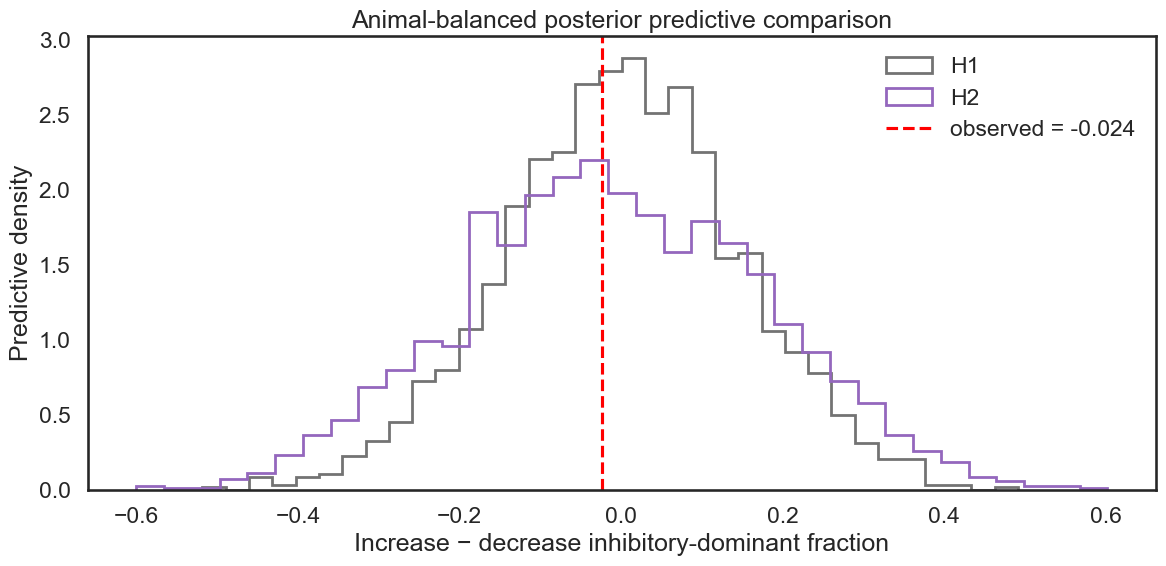

Leave-one-animal-out delta ELPD (H2 − H1): -6.08


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for simulations, label, color in (
    (h1_ppc, "H1", "0.45"),
    (h2_ppc, "H2", "tab:purple"),
):
    delta = (
        simulations[(COMPARISON_GROUP, "p_inhibitory")]
        - simulations[(BASELINE_GROUP, "p_inhibitory")]
    )
    ax.hist(
        delta,
        bins=35,
        density=True,
        histtype="step",
        linewidth=2,
        color=color,
        label=label,
    )
ax.axvline(
    observed_delta_p,
    color="red",
    linestyle="--",
    label=f"observed = {observed_delta_p:+.3f}",
)
ax.set_xlabel(
    f"{COMPARISON_GROUP.capitalize()} − {BASELINE_GROUP} "
    "inhibitory-dominant fraction"
)
ax.set_ylabel("Predictive density")
ax.set_title(f"{WEIGHTING_LABEL} posterior predictive comparison")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

if loao_is_estimable:
    print(
        "Leave-one-animal-out delta ELPD (H2 − H1): "
        f"{h2_elpd - h1_elpd:+.2f}"
    )